In [2]:
# ============================================================
# CELL 1 — Setup, Data Loading, Label Unification
# Run this first. ~3 min.
# ============================================================

import os, random, warnings, time, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report)
from datasets import load_dataset

# ── GPU ───────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    torch.backends.cudnn.benchmark = True

# ── Config ────────────────────────────────────────────────────
class CFG:
    # ── CHANGE THESE ──────────────────────────────────────────
    LOCAL_DATA_DIR = "data"
    SAVE_DIR       = "outputs"
    # ──────────────────────────────────────────────────────────
    LOCAL_DATASETS = {
        "airline":  "airline.tsv",
        "eco_news": "eco_news.tsv",
        "glo_warm": "glo_warm.tsv",
        "text_emo": "text_emo.tsv",
    }
    DOMAIN_NAMES = ["airline","eco_news","glo_warm","text_emo","emotion_hf","tweet_eval"]
    SEED         = 42
    MAX_LEN      = 128
    NUM_WORKERS  = 0       # Windows: must be 0

os.makedirs(CFG.SAVE_DIR, exist_ok=True)

def set_seed(s=CFG.SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed()

# ── Unified label map (25 raw → 11 clean) ────────────────────
LABEL_MAP = {
    # sentiment
    "negative":"negative", "neutral":"neutral", "positive":"positive",
    # tweet_eval integers
    "0":"negative", "1":"neutral", "2":"positive",
    # basic emotions
    "sadness":"sadness", "joy":"joy", "love":"love",
    "anger":"anger",   "fear":"fear", "surprise":"surprise",
    # text_emo consolidations
    "happiness":"joy", "fun":"joy", "enthusiasm":"joy",
    "hate":"anger",    "worry":"fear",
    "boredom":"neutral","empty":"neutral","relief":"neutral",
    # stance
    "yes":"positive_stance", "no":"negative_stance", "not sure":"neutral_stance",
    "y":"positive_stance",   "n":"negative_stance",
}

# ── Load local TSVs ───────────────────────────────────────────
print("\n[1/3] Loading local datasets...")
parts = []
for name, fname in CFG.LOCAL_DATASETS.items():
    df  = pd.read_csv(os.path.join(CFG.LOCAL_DATA_DIR, fname),
                      sep="\t", encoding="latin1")
    df  = df.rename(columns={c:c.strip() for c in df.columns})
    tmp = df[["text","label"]].copy()
    tmp["source"] = name
    parts.append(tmp)
    print(f"  {name:12s}: {len(df):>7,} rows | labels: {sorted(df['label'].astype(str).unique().tolist())}")

# ── HuggingFace ───────────────────────────────────────────────
print("\n[2/3] Loading HuggingFace datasets...")
EMOTION_MAP = {"0":"sadness","1":"joy","2":"love","3":"anger","4":"fear","5":"surprise"}

def hf_to_df(ds, source, label_map=None):
    rows = []
    for split in ds.keys():
        for ex in ds[split]:
            lbl = str(ex["label"])
            if label_map: lbl = label_map.get(lbl, lbl)
            rows.append({"text": ex["text"], "label": lbl, "source": source})
    return pd.DataFrame(rows)

parts.append(hf_to_df(load_dataset("dair-ai/emotion"), "emotion_hf", EMOTION_MAP))
parts.append(hf_to_df(load_dataset("tweet_eval","sentiment"), "tweet_eval"))
print(f"  emotion_hf  : {len(parts[-2]):>7,} rows")
print(f"  tweet_eval  : {len(parts[-1]):>7,} rows")

# ── Build & clean corpus ──────────────────────────────────────
print("\n[3/3] Building corpus...")
import re
def clean(text):
    text = str(text)
    text = re.sub(r"&amp;|&lt;|&gt;|&quot;|&#39;", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\bRT\b", " ", text)
    text = text.encode("ascii","ignore").decode("ascii")
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[^a-zA-Z\s.,!?']", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df = pd.concat(parts, ignore_index=True)
df["text"]   = df["text"].apply(clean)
df["label"]  = df["label"].astype(str).str.strip().str.lower()
df["source"] = df["source"].astype(str)

# Apply unified label map
df = df[df["label"].isin(LABEL_MAP)].copy()
df["label"] = df["label"].map(LABEL_MAP)
df = df[df["text"].str.len() > 3].reset_index(drop=True)

# Encode
le_emotion = LabelEncoder()
df["label_id"] = le_emotion.fit_transform(df["label"])
le_domain = LabelEncoder()
le_domain.fit(CFG.DOMAIN_NAMES)
df["domain_id"] = le_domain.transform(df["source"])

NUM_CLASSES = len(le_emotion.classes_)
NUM_DOMAINS = len(CFG.DOMAIN_NAMES)

print(f"\n  Total rows  : {len(df):,}")
print(f"  Classes     : {NUM_CLASSES} → {list(le_emotion.classes_)}")
print(f"\n  Distribution:")
for lbl, cnt in df["label"].value_counts().items():
    print(f"    {lbl:20s} {cnt:>7,}")

# ── Stratified 70/15/15 split ─────────────────────────────────
X_train, X_tmp, y_train, y_tmp = train_test_split(
    df["text"], df["label_id"],
    test_size=0.30, random_state=CFG.SEED, stratify=df["label_id"]
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.50, random_state=CFG.SEED, stratify=y_tmp
)
for arr in [X_train,X_val,X_test,y_train,y_val,y_test]:
    arr.reset_index(drop=True, inplace=True)

# Also keep per-domain test sets for domain breakdown later
domain_test = {}
for dom in CFG.DOMAIN_NAMES:
    mask = df["source"] == dom
    domain_test[dom] = {
        "text": df.loc[mask,"text"].reset_index(drop=True),
        "label": df.loc[mask,"label_id"].reset_index(drop=True),
    }

print(f"\n  Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}")
print("\n✓ Cell 1 complete.")

GPU  : NVIDIA RTX A6000
VRAM : 51.5 GB

[1/3] Loading local datasets...
  airline     :  14,640 rows | labels: ['negative', 'neutral', 'positive']
  eco_news    :   8,000 rows | labels: ['no', 'not sure', 'yes']
  glo_warm    :   4,225 rows | labels: ['N', 'No', 'Y', 'Yes']
  text_emo    :  40,000 rows | labels: ['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']

[2/3] Loading HuggingFace datasets...


  emotion_hf  :  20,000 rows
  tweet_eval  :  59,899 rows

[3/3] Building corpus...

  Total rows  : 146,643
  Classes     : 12 → ['anger', 'fear', 'joy', 'love', 'negative', 'negative_stance', 'neutral', 'neutral_stance', 'positive', 'positive_stance', 'sadness', 'surprise']

  Distribution:
    neutral               41,649
    positive              23,406
    negative              20,555
    joy                   14,501
    sadness               10,957
    fear                  10,823
    negative_stance        7,685
    love                   5,480
    positive_stance        4,531
    anger                  4,142
    surprise               2,905
    neutral_stance             9

  Train : 102,650 | Val : 21,996 | Test : 21,997

✓ Cell 1 complete.


In [3]:
# ============================================================
# CELL 2 — Classical Models
# Naive Bayes · Logistic Regression · SVM · XGBoost
# Expected runtime: ~15–25 min (SVM is slowest)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import MaxAbsScaler
import xgboost as xgb
import numpy as np

# ── Expected Calibration Error ────────────────────────────────
def compute_ece(y_true, y_prob, n_bins=10):
    """
    Expected Calibration Error — measures how well predicted
    probabilities match actual frequencies.
    Lower = better calibrated. Range [0, 1].
    """
    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    correct     = (predictions == y_true).astype(float)
    ece = 0.0
    for b in range(n_bins):
        lo, hi = b/n_bins, (b+1)/n_bins
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() > 0:
            ece += mask.sum() * abs(correct[mask].mean() - confidences[mask].mean())
    return ece / len(y_true)

# ── Metric bundle ─────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob=None, model_name=""):
    acc   = accuracy_score(y_true, y_pred)
    mac_f = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    wt_f  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mac_p = precision_score(y_true, y_pred, average="macro",    zero_division=0)
    mac_r = recall_score(y_true, y_pred, average="macro",    zero_division=0)
    ece   = compute_ece(y_true, y_prob) if y_prob is not None else None
    return {
        "Model":       model_name,
        "Accuracy":    round(acc,   4),
        "Precision":   round(mac_p, 4),
        "Recall":      round(mac_r, 4),
        "Macro-F1":    round(mac_f, 4),
        "Weighted-F1": round(wt_f,  4),
        "ECE":         round(ece,   4) if ece is not None else "—",
    }

# ── TF-IDF vectoriser shared across all classical models ──────
print("Fitting TF-IDF vectoriser...")
t0 = time.time()
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=100_000,
    sublinear_tf=True,
    min_df=2,
    strip_accents="unicode",
)
X_tr_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_te_tfidf  = tfidf.transform(X_test)
print(f"  Vocab size : {len(tfidf.vocabulary_):,}  ({time.time()-t0:.1f}s)")

# Per-domain TF-IDF matrices for domain breakdown
dom_tfidf = {
    dom: tfidf.transform(domain_test[dom]["text"])
    for dom in CFG.DOMAIN_NAMES
}

classical_results = []   # combined test set results
domain_results    = {}   # domain breakdown: model → {domain → metrics}

# ─────────────────────────────────────────────────────────────
# MODEL 1: Complement Naive Bayes
# Better than Multinomial NB for imbalanced text classification
# ─────────────────────────────────────────────────────────────
print("\n[1/4] Complement Naive Bayes...")
t0  = time.time()
cnb = CalibratedClassifierCV(
    ComplementNB(alpha=0.3),   # alpha=smoothing; 0.3 works well for short texts
    cv=3, method="isotonic"
)
cnb.fit(X_tr_tfidf, y_train)
preds = cnb.predict(X_te_tfidf)
probs = cnb.predict_proba(X_te_tfidf)
res   = compute_metrics(y_test, preds, probs, "Complement NB")
classical_results.append(res)
print(f"  Acc={res['Accuracy']}  Macro-F1={res['Macro-F1']}  ECE={res['ECE']}  ({time.time()-t0:.0f}s)")

# Per-domain
domain_results["Complement NB"] = {}
for dom in CFG.DOMAIN_NAMES:
    yt = domain_test[dom]["label"].values
    yp = cnb.predict(dom_tfidf[dom])
    yb = cnb.predict_proba(dom_tfidf[dom])
    domain_results["Complement NB"][dom] = compute_metrics(yt, yp, yb, dom)

# ─────────────────────────────────────────────────────────────
# MODEL 2: Logistic Regression
# Strong linear baseline for text; saga solver handles large vocab
# ─────────────────────────────────────────────────────────────
print("\n[2/4] Logistic Regression...")
t0 = time.time()
lr = LogisticRegression(
    C=5.0,              # regularisation; 5.0 slightly looser than default
    max_iter=1000,
    solver="saga",      # handles large sparse matrices efficiently
    multi_class="multinomial",
    class_weight="balanced",
    n_jobs=-1,
    random_state=CFG.SEED,
)
lr.fit(X_tr_tfidf, y_train)
preds = lr.predict(X_te_tfidf)
probs = lr.predict_proba(X_te_tfidf)
res   = compute_metrics(y_test, preds, probs, "Logistic Regression")
classical_results.append(res)
print(f"  Acc={res['Accuracy']}  Macro-F1={res['Macro-F1']}  ECE={res['ECE']}  ({time.time()-t0:.0f}s)")

domain_results["Logistic Regression"] = {}
for dom in CFG.DOMAIN_NAMES:
    yt = domain_test[dom]["label"].values
    yp = lr.predict(dom_tfidf[dom])
    yb = lr.predict_proba(dom_tfidf[dom])
    domain_results["Logistic Regression"][dom] = compute_metrics(yt, yp, yb, dom)

# ─────────────────────────────────────────────────────────────
# MODEL 3: Linear SVM (with Platt calibration for probabilities)
# Best classical model for text; LinearSVC is faster than SVC
# ─────────────────────────────────────────────────────────────
print("\n[3/4] Linear SVM...")
t0  = time.time()
svm = CalibratedClassifierCV(
    LinearSVC(
        C=0.5,           # lower C = stronger regularisation; prevents overfit on imbalanced
        max_iter=3000,
        class_weight="balanced",
        random_state=CFG.SEED,
    ),
    cv=3, method="sigmoid"   # Platt scaling for probability calibration
)
svm.fit(X_tr_tfidf, y_train)
preds = svm.predict(X_te_tfidf)
probs = svm.predict_proba(X_te_tfidf)
res   = compute_metrics(y_test, preds, probs, "Linear SVM")
classical_results.append(res)
print(f"  Acc={res['Accuracy']}  Macro-F1={res['Macro-F1']}  ECE={res['ECE']}  ({time.time()-t0:.0f}s)")

domain_results["Linear SVM"] = {}
for dom in CFG.DOMAIN_NAMES:
    yt = domain_test[dom]["label"].values
    yp = svm.predict(dom_tfidf[dom])
    yb = svm.predict_proba(dom_tfidf[dom])
    domain_results["Linear SVM"][dom] = compute_metrics(yt, yp, yb, dom)

# ─────────────────────────────────────────────────────────────
# MODEL 4: XGBoost
# Gradient-boosted trees on TF-IDF; strong non-linear baseline
# ─────────────────────────────────────────────────────────────
print("\n[4/4] XGBoost...")
t0  = time.time()

# Scale to [0,1] — XGBoost doesn't handle negative sparse values well
scaler      = MaxAbsScaler()
X_tr_sc     = scaler.fit_transform(X_tr_tfidf)
X_te_sc     = scaler.transform(X_te_tfidf)

xgb_model = xgb.XGBClassifier(
    n_estimators     = 500,
    max_depth        = 7,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.6,
    use_label_encoder= False,
    eval_metric      = "mlogloss",
    tree_method      = "hist",      # fastest on CPU/GPU
    device           = "cuda" if torch.cuda.is_available() else "cpu",
    random_state     = CFG.SEED,
    n_jobs           = -1,
)
xgb_model.fit(
    X_tr_sc, y_train,
    eval_set=[(scaler.transform(X_val_tfidf), y_val)],
    verbose=100,
)
preds = xgb_model.predict(X_te_sc)
probs = xgb_model.predict_proba(X_te_sc)
res   = compute_metrics(y_test, preds, probs, "XGBoost")
classical_results.append(res)
print(f"  Acc={res['Accuracy']}  Macro-F1={res['Macro-F1']}  ECE={res['ECE']}  ({time.time()-t0:.0f}s)")

domain_results["XGBoost"] = {}
for dom in CFG.DOMAIN_NAMES:
    yt = domain_test[dom]["label"].values
    yp = xgb_model.predict(scaler.transform(dom_tfidf[dom]))
    yb = xgb_model.predict_proba(scaler.transform(dom_tfidf[dom]))
    domain_results["XGBoost"][dom] = compute_metrics(yt, yp, yb, dom)

# ── Classical results summary ─────────────────────────────────
print("\n" + "="*70)
print("CLASSICAL MODELS — Combined Test Set")
print("="*70)
cl_df = pd.DataFrame(classical_results)
print(cl_df.to_string(index=False))
cl_df.to_csv(f"{CFG.SAVE_DIR}/classical_results.csv", index=False)

# Save for Cell 7
with open(f"{CFG.SAVE_DIR}/domain_results_classical.pkl","wb") as f:
    pickle.dump(domain_results, f)

print("\n✓ Cell 2 complete.")

Fitting TF-IDF vectoriser...
  Vocab size : 100,000  (9.4s)

[1/4] Complement Naive Bayes...
  Acc=0.5725  Macro-F1=0.5079  ECE=0.0556  (1s)

[2/4] Logistic Regression...
  Acc=0.5687  Macro-F1=0.5018  ECE=0.0657  (353s)

[3/4] Linear SVM...
  Acc=0.6084  Macro-F1=0.5363  ECE=0.0602  (16s)

[4/4] XGBoost...
[0]	validation_0-mlogloss:16.66811
[100]	validation_0-mlogloss:29.95775
[200]	validation_0-mlogloss:29.95775
[300]	validation_0-mlogloss:29.95775
[400]	validation_0-mlogloss:29.95775
[499]	validation_0-mlogloss:29.95775
  Acc=0.189  Macro-F1=0.0484  ECE=0.8109  (46s)

CLASSICAL MODELS — Combined Test Set
              Model  Accuracy  Precision  Recall  Macro-F1  Weighted-F1    ECE
      Complement NB    0.5725     0.5941  0.4715    0.5079       0.5645 0.0556
Logistic Regression    0.5687     0.5002  0.5091    0.5018       0.5697 0.0657
         Linear SVM    0.6084     0.5940  0.5095    0.5363       0.6027 0.0602
            XGBoost    0.1890     0.0525  0.0926    0.0484       0.12

In [4]:
# ============================================================
# CELL 3 — Shared Neural Utilities
# Dataset class, metrics, ECE for all neural models.
# Run once before Cells 4 and 5. Instant.
# ============================================================

# ── Tokeniser ─────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# ── ECE for neural models ─────────────────────────────────────
def compute_ece_np(y_true, y_prob, n_bins=10):
    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    correct     = (predictions == np.array(y_true)).astype(float)
    ece = 0.0
    for b in range(n_bins):
        lo, hi = b/n_bins, (b+1)/n_bins
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() > 0:
            ece += mask.sum() * abs(correct[mask].mean() - confidences[mask].mean())
    return ece / len(y_true)

def full_metrics(y_true, y_pred, y_prob, model_name):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    return {
        "Model":       model_name,
        "Accuracy":    round(accuracy_score(y_true, y_pred), 4),
        "Precision":   round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Recall":      round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Macro-F1":    round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Weighted-F1": round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "ECE":         round(compute_ece_np(y_true, y_prob), 4),
    }

# ── GloVe dataset (char-level fallback for RNN) ───────────────
class TextDataset(Dataset):
    """
    Simple bag-of-indices dataset using the DistilBERT tokenizer vocab.
    Used by RNN/LSTM/GRU models (they don't use attention masks).
    """
    def __init__(self, texts, labels, max_len=CFG.MAX_LEN):
        enc = tokenizer(
            list(texts), padding="max_length", truncation=True,
            max_length=max_len, return_tensors="pt"
        )
        self.ids    = enc["input_ids"]
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {"ids": self.ids[idx], "label": self.labels[idx]}

class TransformerDataset(Dataset):
    """Full tokenised dataset with attention masks for transformers."""
    def __init__(self, texts, labels, max_len=CFG.MAX_LEN):
        enc = tokenizer(
            list(texts), padding="max_length", truncation=True,
            max_length=max_len, return_tensors="pt"
        )
        self.ids    = enc["input_ids"]
        self.masks  = enc["attention_mask"]
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            "ids":   self.ids[idx],
            "masks": self.masks[idx],
            "label": self.labels[idx],
        }

def make_rnn_loaders(batch=128):
    tr = DataLoader(TextDataset(X_train, y_train), batch_size=batch,
                    shuffle=True,  num_workers=0, pin_memory=True)
    vl = DataLoader(TextDataset(X_val,   y_val),   batch_size=batch*2,
                    shuffle=False, num_workers=0, pin_memory=True)
    te = DataLoader(TextDataset(X_test,  y_test),  batch_size=batch*2,
                    shuffle=False, num_workers=0, pin_memory=True)
    return tr, vl, te

def make_dom_rnn_loader(dom, batch=256):
    return DataLoader(
        TextDataset(domain_test[dom]["text"], domain_test[dom]["label"]),
        batch_size=batch, shuffle=False, num_workers=0
    )

def make_transformer_loaders(batch=128):
    tr = DataLoader(TransformerDataset(X_train, y_train), batch_size=batch,
                    shuffle=True,  num_workers=0, pin_memory=True)
    vl = DataLoader(TransformerDataset(X_val,   y_val),   batch_size=batch*2,
                    shuffle=False, num_workers=0, pin_memory=True)
    te = DataLoader(TransformerDataset(X_test,  y_test),  batch_size=batch*2,
                    shuffle=False, num_workers=0, pin_memory=True)
    return tr, vl, te

def make_dom_transformer_loader(dom, batch=256):
    return DataLoader(
        TransformerDataset(domain_test[dom]["text"], domain_test[dom]["label"]),
        batch_size=batch, shuffle=False, num_workers=0
    )

# ── Generic train + eval loop for RNN models ─────────────────
def train_rnn(model, train_loader, val_loader, epochs, lr, name):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss()
    scaler = GradScaler(enabled=True)
    best_f1, best_state = 0.0, None

    print(f"\n  Training {name} | epochs={epochs} lr={lr}")
    for ep in range(1, epochs+1):
        model.train(); ep_loss = 0.0; t0 = time.time()
        for batch in train_loader:
            opt.zero_grad(set_to_none=True)
            with autocast():
                out  = model(batch["ids"].to(device))
                loss = crit(out, batch["label"].to(device))
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            ep_loss += loss.item()
        sch.step()

        # Val
        model.eval(); preds, trues = [], []
        with torch.no_grad(), autocast():
            for batch in val_loader:
                logits = model(batch["ids"].to(device))
                preds.extend(logits.argmax(-1).cpu().numpy())
                trues.extend(batch["label"].numpy())
        vf1 = f1_score(trues, preds, average="macro", zero_division=0)
        star = " ★" if vf1 > best_f1 else ""
        print(f"    ep {ep:02d}/{epochs}  loss={ep_loss/len(train_loader):.4f}"
              f"  val_f1={vf1:.4f}{star}  ({time.time()-t0:.0f}s)")
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k:v.clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model

def eval_rnn(model, loader):
    model.eval(); preds, trues, probs_all = [], [], []
    with torch.no_grad(), autocast():
        for batch in loader:
            logits = model(batch["ids"].to(device))
            p = F.softmax(logits, dim=-1).cpu().numpy()
            probs_all.extend(p)
            preds.extend(logits.argmax(-1).cpu().numpy())
            trues.extend(batch["label"].numpy())
    return np.array(trues), np.array(preds), np.array(probs_all)

# ── Generic train + eval loop for Transformer models ─────────
def train_transformer(model, train_loader, val_loader, epochs, lr, name):
    opt    = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total  = len(train_loader) * epochs
    sch    = get_linear_schedule_with_warmup(opt,
                num_warmup_steps=int(0.06*total),
                num_training_steps=total)
    scaler = GradScaler(enabled=True)
    best_f1, best_state = 0.0, None

    print(f"\n  Training {name} | epochs={epochs} lr={lr}")
    for ep in range(1, epochs+1):
        model.train(); ep_loss = 0.0; t0 = time.time()
        for batch in train_loader:
            opt.zero_grad(set_to_none=True)
            with autocast():
                out  = model(input_ids=batch["ids"].to(device),
                             attention_mask=batch["masks"].to(device))
                loss = F.cross_entropy(out.logits, batch["label"].to(device))
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sch.step()
            ep_loss += loss.item()

        model.eval(); preds, trues = [], []
        with torch.no_grad(), autocast():
            for batch in val_loader:
                logits = model(input_ids=batch["ids"].to(device),
                               attention_mask=batch["masks"].to(device)).logits
                preds.extend(logits.argmax(-1).cpu().numpy())
                trues.extend(batch["label"].numpy())
        vf1  = f1_score(trues, preds, average="macro", zero_division=0)
        used = torch.cuda.memory_reserved(0)/1e9
        star = " ★" if vf1 > best_f1 else ""
        print(f"    ep {ep:02d}/{epochs}  loss={ep_loss/len(train_loader):.4f}"
              f"  val_f1={vf1:.4f}{star}  VRAM={used:.1f}GB  ({time.time()-t0:.0f}s)")
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k:v.clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model

def eval_transformer(model, loader):
    model.eval(); preds, trues, probs_all = [], [], []
    with torch.no_grad(), autocast():
        for batch in loader:
            logits = model(input_ids=batch["ids"].to(device),
                           attention_mask=batch["masks"].to(device)).logits
            p = F.softmax(logits, dim=-1).cpu().numpy()
            probs_all.extend(p)
            preds.extend(logits.argmax(-1).cpu().numpy())
            trues.extend(batch["label"].numpy())
    return np.array(trues), np.array(preds), np.array(probs_all)

VOCAB_SIZE = tokenizer.vocab_size
print(f"Vocab size : {VOCAB_SIZE:,}")
print("✓ Cell 3 complete. Neural utilities ready.")

Vocab size : 30,522
✓ Cell 3 complete. Neural utilities ready.


In [5]:
# ============================================================
# CELL 4 — Recurrent Models: LSTM · BiLSTM · GRU
# A6000: ~20–30 min total for all three
# ============================================================

# ── Model architectures ───────────────────────────────────────

class LSTMClassifier(nn.Module):
    def __init__(self, vocab, emb=256, hidden=512, layers=2,
                 dropout=0.4, num_classes=NUM_CLASSES):
        super().__init__()
        self.emb     = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm    = nn.LSTM(emb, hidden, layers, batch_first=True,
                               dropout=dropout, bidirectional=False)
        self.drop    = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(hidden)
        self.fc      = nn.Linear(hidden, num_classes)

    def forward(self, x):
        e = self.drop(self.emb(x))
        _, (h, _) = self.lstm(e)
        h = self.norm(self.drop(h[-1]))
        return self.fc(h)


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab, emb=256, hidden=512, layers=2,
                 dropout=0.4, num_classes=NUM_CLASSES):
        super().__init__()
        self.emb  = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hidden, layers, batch_first=True,
                            dropout=dropout, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc   = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        e = self.drop(self.emb(x))
        _, (h, _) = self.lstm(e)
        # concat last forward and last backward hidden states
        h = torch.cat([h[-2], h[-1]], dim=1)
        h = self.norm(self.drop(h))
        return self.fc(h)


class GRUClassifier(nn.Module):
    def __init__(self, vocab, emb=256, hidden=512, layers=2,
                 dropout=0.4, num_classes=NUM_CLASSES):
        super().__init__()
        self.emb  = nn.Embedding(vocab, emb, padding_idx=0)
        self.gru  = nn.GRU(emb, hidden, layers, batch_first=True,
                           dropout=dropout, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc   = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        e = self.drop(self.emb(x))
        _, h = self.gru(e)
        h = torch.cat([h[-2], h[-1]], dim=1)
        h = self.norm(self.drop(h))
        return self.fc(h)


# ── Shared config for all RNN models ─────────────────────────
RNN_EPOCHS = 25
RNN_LR     = 3e-4
RNN_BATCH  = 256

train_loader, val_loader, test_loader = make_rnn_loaders(batch=RNN_BATCH)

rnn_results    = []
domain_results_rnn = {}

# ─────────────────────────────────────────────────────────────
# MODEL 5: LSTM
# ─────────────────────────────────────────────────────────────
print("="*60)
print("LSTM")
print("="*60)
lstm = LSTMClassifier(VOCAB_SIZE).to(device)
lstm = train_rnn(lstm, train_loader, val_loader, RNN_EPOCHS, RNN_LR, "LSTM")
trues, preds, probs = eval_rnn(lstm, test_loader)
res = full_metrics(trues, preds, probs, "LSTM")
rnn_results.append(res)
print(f"\n  TEST → Acc={res['Accuracy']}  Macro-F1={res['Macro-F1']}  ECE={res['ECE']}")
torch.save(lstm.state_dict(), f"{CFG.SAVE_DIR}/lstm_best.pt")

domain_results_rnn["LSTM"] = {}
for dom in CFG.DOMAIN_NAMES:
    ldr = make_dom_rnn_loader(dom)
    yt, yp, yb = eval_rnn(lstm, ldr)
    domain_results_rnn["LSTM"][dom] = full_metrics(yt, yp, yb, dom)

del lstm; torch.cuda.empty_cache()

# ─────────────────────────────────────────────────────────────
# MODEL 6: BiLSTM
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("BiLSTM")
print("="*60)
bilstm = BiLSTMClassifier(VOCAB_SIZE).to(device)
bilstm = train_rnn(bilstm, train_loader, val_loader, RNN_EPOCHS, RNN_LR, "BiLSTM")
trues, preds, probs = eval_rnn(bilstm, test_loader)
res = full_metrics(trues, preds, probs, "BiLSTM")
rnn_results.append(res)
print(f"\n  TEST → Acc={res['Accuracy']}  Macro-F1={res['Macro-F1']}  ECE={res['ECE']}")
torch.save(bilstm.state_dict(), f"{CFG.SAVE_DIR}/bilstm_best.pt")

domain_results_rnn["BiLSTM"] = {}
for dom in CFG.DOMAIN_NAMES:
    ldr = make_dom_rnn_loader(dom)
    yt, yp, yb = eval_rnn(bilstm, ldr)
    domain_results_rnn["BiLSTM"][dom] = full_metrics(yt, yp, yb, dom)

del bilstm; torch.cuda.empty_cache()

# ─────────────────────────────────────────────────────────────
# MODEL 7: GRU
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("GRU")
print("="*60)
gru = GRUClassifier(VOCAB_SIZE).to(device)
gru = train_rnn(gru, train_loader, val_loader, RNN_EPOCHS, RNN_LR, "GRU")
trues, preds, probs = eval_rnn(gru, test_loader)
res = full_metrics(trues, preds, probs, "GRU")
rnn_results.append(res)
print(f"\n  TEST → Acc={res['Accuracy']}  Macro-F1={res['Macro-F1']}  ECE={res['ECE']}")
torch.save(gru.state_dict(), f"{CFG.SAVE_DIR}/gru_best.pt")

domain_results_rnn["GRU"] = {}
for dom in CFG.DOMAIN_NAMES:
    ldr = make_dom_rnn_loader(dom)
    yt, yp, yb = eval_rnn(gru, ldr)
    domain_results_rnn["GRU"][dom] = full_metrics(yt, yp, yb, dom)

del gru; torch.cuda.empty_cache()

# ── RNN results summary ───────────────────────────────────────
print("\n" + "="*70)
print("RECURRENT MODELS — Combined Test Set")
print("="*70)
rnn_df = pd.DataFrame(rnn_results)
print(rnn_df.to_string(index=False))
rnn_df.to_csv(f"{CFG.SAVE_DIR}/rnn_results.csv", index=False)

with open(f"{CFG.SAVE_DIR}/domain_results_rnn.pkl","wb") as f:
    pickle.dump(domain_results_rnn, f)

print("\n✓ Cell 4 complete.")

LSTM

  Training LSTM | epochs=25 lr=0.0003
    ep 01/25  loss=1.9831  val_f1=0.1077 ★  (14s)
    ep 02/25  loss=2.0032  val_f1=0.1077  (12s)
    ep 03/25  loss=1.9548  val_f1=0.1079 ★  (12s)
    ep 04/25  loss=1.9486  val_f1=0.1077  (12s)
    ep 05/25  loss=1.9408  val_f1=0.1077  (12s)
    ep 06/25  loss=1.7787  val_f1=0.1443 ★  (12s)
    ep 07/25  loss=1.6001  val_f1=0.2047 ★  (12s)
    ep 08/25  loss=1.5258  val_f1=0.2237 ★  (12s)
    ep 09/25  loss=1.4728  val_f1=0.2553 ★  (13s)
    ep 10/25  loss=1.4404  val_f1=0.2522  (12s)
    ep 11/25  loss=1.4011  val_f1=0.2995 ★  (12s)
    ep 12/25  loss=1.3517  val_f1=0.3202 ★  (13s)
    ep 13/25  loss=1.3022  val_f1=0.3565 ★  (13s)
    ep 14/25  loss=1.2638  val_f1=0.3562  (12s)
    ep 15/25  loss=1.2367  val_f1=0.3600 ★  (12s)
    ep 16/25  loss=1.2119  val_f1=0.3614 ★  (12s)
    ep 17/25  loss=1.1923  val_f1=0.3676 ★  (13s)
    ep 18/25  loss=1.1784  val_f1=0.3625  (12s)
    ep 19/25  loss=1.1661  val_f1=0.3828 ★  (13s)
    ep 20/25  loss

In [6]:
# ============================================================
# CELL 5 — Transformer Models: DistilBERT · BERT-base
# A6000: DistilBERT ~25 min · BERT ~40 min
# ============================================================

transformer_results    = []
domain_results_trans   = {}

# ── Shared config ─────────────────────────────────────────────
TRANS_BATCH  = 128
TRANS_EPOCHS = 10
TRANS_LR     = 2e-5

train_loader, val_loader, test_loader = make_transformer_loaders(batch=TRANS_BATCH)

# ─────────────────────────────────────────────────────────────
# MODEL 8: DistilBERT
# 66M params, 40% smaller than BERT, 97% of BERT performance
# ─────────────────────────────────────────────────────────────
print("="*60)
print("DistilBERT-base-uncased")
print("="*60)

distilbert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
).to(device)

distilbert = train_transformer(
    distilbert, train_loader, val_loader,
    TRANS_EPOCHS, TRANS_LR, "DistilBERT"
)
trues, preds, probs = eval_transformer(distilbert, test_loader)
res = full_metrics(trues, preds, probs, "DistilBERT")
transformer_results.append(res)
print(f"\n  TEST → Acc={res['Accuracy']}  Macro-F1={res['Macro-F1']}  ECE={res['ECE']}")
torch.save(distilbert.state_dict(), f"{CFG.SAVE_DIR}/distilbert_best.pt")

# Per-domain
domain_results_trans["DistilBERT"] = {}
for dom in CFG.DOMAIN_NAMES:
    ldr = make_dom_transformer_loader(dom)
    yt, yp, yb = eval_transformer(distilbert, ldr)
    domain_results_trans["DistilBERT"][dom] = full_metrics(yt, yp, yb, dom)
    print(f"    {dom:12s} → Macro-F1={domain_results_trans['DistilBERT'][dom]['Macro-F1']}")

del distilbert; torch.cuda.empty_cache()

# ─────────────────────────────────────────────────────────────
# MODEL 9: BERT-base-uncased
# 110M params, full BERT — best expected performance
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("BERT-base-uncased")
print("="*60)

# BERT needs slightly lower LR and more warmup than DistilBERT
BERT_LR     = 2e-5
BERT_EPOCHS = 10

bert = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
).to(device)

bert = train_transformer(
    bert, train_loader, val_loader,
    BERT_EPOCHS, BERT_LR, "BERT"
)
trues, preds, probs = eval_transformer(bert, test_loader)
res = full_metrics(trues, preds, probs, "BERT-base")
transformer_results.append(res)
print(f"\n  TEST → Acc={res['Accuracy']}  Macro-F1={res['Macro-F1']}  ECE={res['ECE']}")
torch.save(bert.state_dict(), f"{CFG.SAVE_DIR}/bert_best.pt")

domain_results_trans["BERT-base"] = {}
for dom in CFG.DOMAIN_NAMES:
    ldr = make_dom_transformer_loader(dom)
    yt, yp, yb = eval_transformer(bert, ldr)
    domain_results_trans["BERT-base"][dom] = full_metrics(yt, yp, yb, dom)
    print(f"    {dom:12s} → Macro-F1={domain_results_trans['BERT-base'][dom]['Macro-F1']}")

del bert; torch.cuda.empty_cache()

# ── Transformer results summary ───────────────────────────────
print("\n" + "="*70)
print("TRANSFORMER MODELS — Combined Test Set")
print("="*70)
trans_df = pd.DataFrame(transformer_results)
print(trans_df.to_string(index=False))
trans_df.to_csv(f"{CFG.SAVE_DIR}/transformer_results.csv", index=False)

with open(f"{CFG.SAVE_DIR}/domain_results_trans.pkl","wb") as f:
    pickle.dump(domain_results_trans, f)

print("\n✓ Cell 5 complete.")

DistilBERT-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3262.20it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Training DistilBERT | epochs=10 lr=2e-05
    ep 01/10  loss=1.4376  val_f1=0.5355 ★  VRAM=5.0GB  (98s)
    ep 02/10  loss=0.8857  val_f1=0.5913 ★  VRAM=5.0GB  (99s)
    ep 03/10  loss=0.7696  val_f1=0.5998 ★  VRAM=5.0GB  (100s)
    ep 04/10  loss=0.6898  val_f1=0.5972  VRAM=5.2GB  (99s)
    ep 05/10  loss=0.6188  val_f1=0.5933  VRAM=5.2GB  (99s)
    ep 06/10  loss=0.5575  val_f1=0.5995  VRAM=5.2GB  (99s)
    ep 07/10  loss=0.5046  val_f1=0.5944  VRAM=5.2GB  (99s)
    ep 08/10  loss=0.4626  val_f1=0.5934  VRAM=5.2GB  (98s)
    ep 09/10  loss=0.4295  val_f1=0.5919  VRAM=5.2GB  (99s)
    ep 10/10  loss=0.4089  val_f1=0.5909  VRAM=5.2GB  (98s)

  TEST → Acc=0.6772  Macro-F1=0.5997  ECE=0.0524
    airline      → Macro-F1=0.2704
    eco_news     → Macro-F1=0.3088
    glo_warm     → Macro-F1=0.5075
    text_emo     → Macro-F1=0.2789
    emotion_hf   → Macro-F1=0.5541
    tweet_eval   → Macro-F1=0.2157

BERT-base-uncased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2590.65it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr


  Training BERT | epochs=10 lr=2e-05
    ep 01/10  loss=1.3978  val_f1=0.5518 ★  VRAM=8.9GB  (191s)
    ep 02/10  loss=0.8404  val_f1=0.6002 ★  VRAM=8.9GB  (190s)
    ep 03/10  loss=0.7160  val_f1=0.6042 ★  VRAM=8.9GB  (192s)
    ep 04/10  loss=0.6178  val_f1=0.5964  VRAM=8.9GB  (191s)
    ep 05/10  loss=0.5331  val_f1=0.6005  VRAM=8.9GB  (192s)
    ep 06/10  loss=0.4595  val_f1=0.5974  VRAM=8.9GB  (191s)
    ep 07/10  loss=0.4033  val_f1=0.5976  VRAM=8.9GB  (193s)
    ep 08/10  loss=0.3546  val_f1=0.5871  VRAM=8.9GB  (191s)
    ep 09/10  loss=0.3230  val_f1=0.5904  VRAM=8.9GB  (193s)
    ep 10/10  loss=0.2991  val_f1=0.5910  VRAM=8.9GB  (190s)

  TEST → Acc=0.6759  Macro-F1=0.5976  ECE=0.0657
    airline      → Macro-F1=0.2807
    eco_news     → Macro-F1=0.1931
    glo_warm     → Macro-F1=0.3318
    text_emo     → Macro-F1=0.3107
    emotion_hf   → Macro-F1=0.6945
    tweet_eval   → Macro-F1=0.2219

TRANSFORMER MODELS — Combined Test Set
     Model  Accuracy  Precision  Recall  Macro

MASTER RESULTS TABLE — All Models, Combined Test Set
              Model  Accuracy  Precision  Recall  Macro-F1  Weighted-F1    ECE    Category
      Complement NB    0.5725     0.5941  0.4715    0.5079       0.5645 0.0556   Classical
Logistic Regression    0.5687     0.5002  0.5091    0.5018       0.5697 0.0657   Classical
         Linear SVM    0.6084     0.5940  0.5095    0.5363       0.6027 0.0602   Classical
            XGBoost    0.1890     0.0525  0.0926    0.0484       0.1217 0.8109   Classical
               LSTM    0.5431     0.4129  0.4033    0.4021       0.5314 0.0833   Recurrent
             BiLSTM    0.6277     0.5894  0.5518    0.5612       0.6264 0.1372   Recurrent
                GRU    0.6320     0.5965  0.5575    0.5690       0.6329 0.1499   Recurrent
         DistilBERT    0.6772     0.6447  0.5805    0.5997       0.6751 0.0524 Transformer
          BERT-base    0.6759     0.6302  0.5856    0.5976       0.6722 0.0657 Transformer

PER-DOMAIN MACRO-F1
              Mo

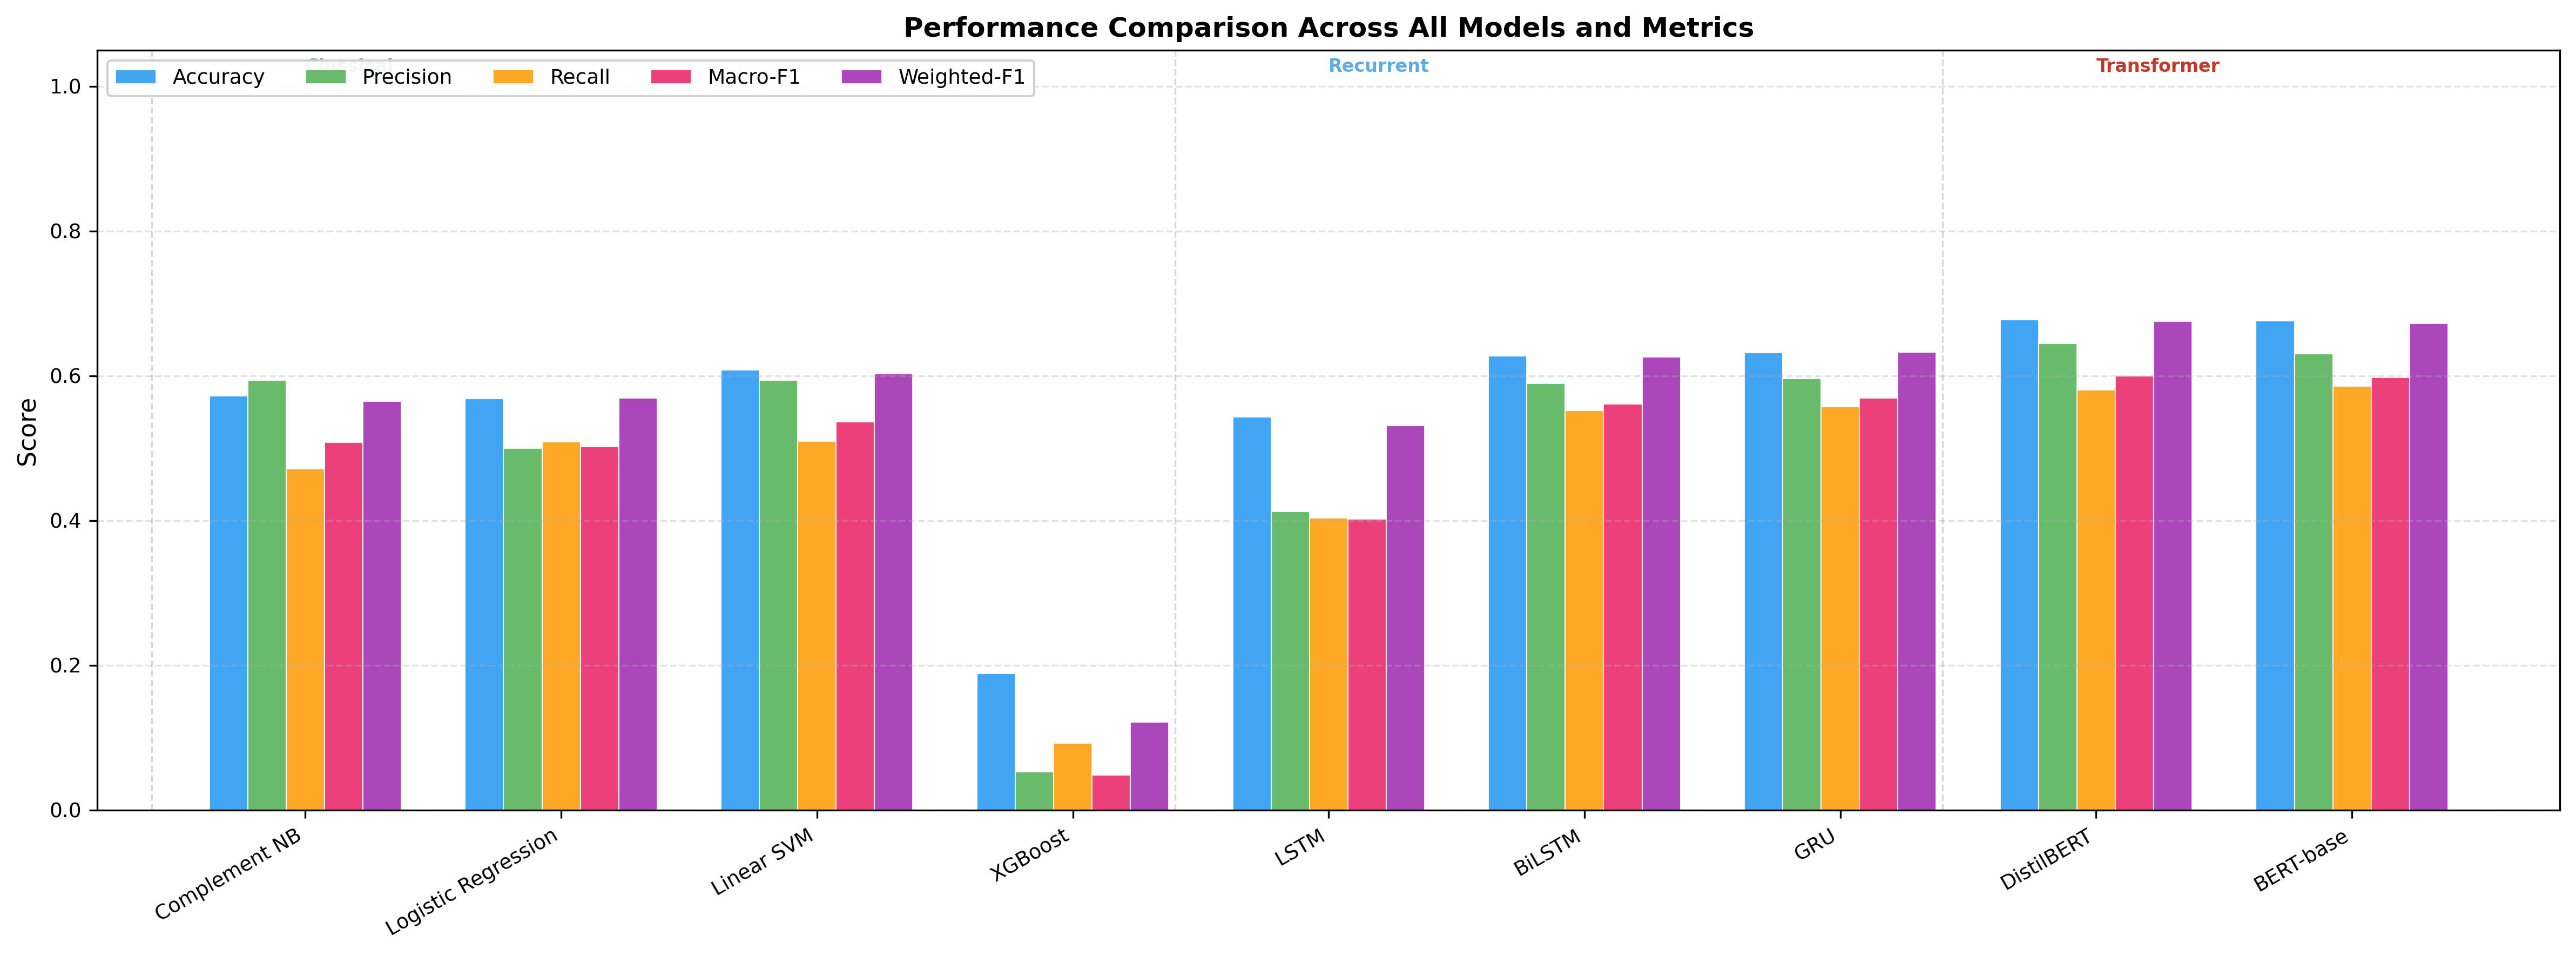

Saved: plot1_all_models_metrics.png


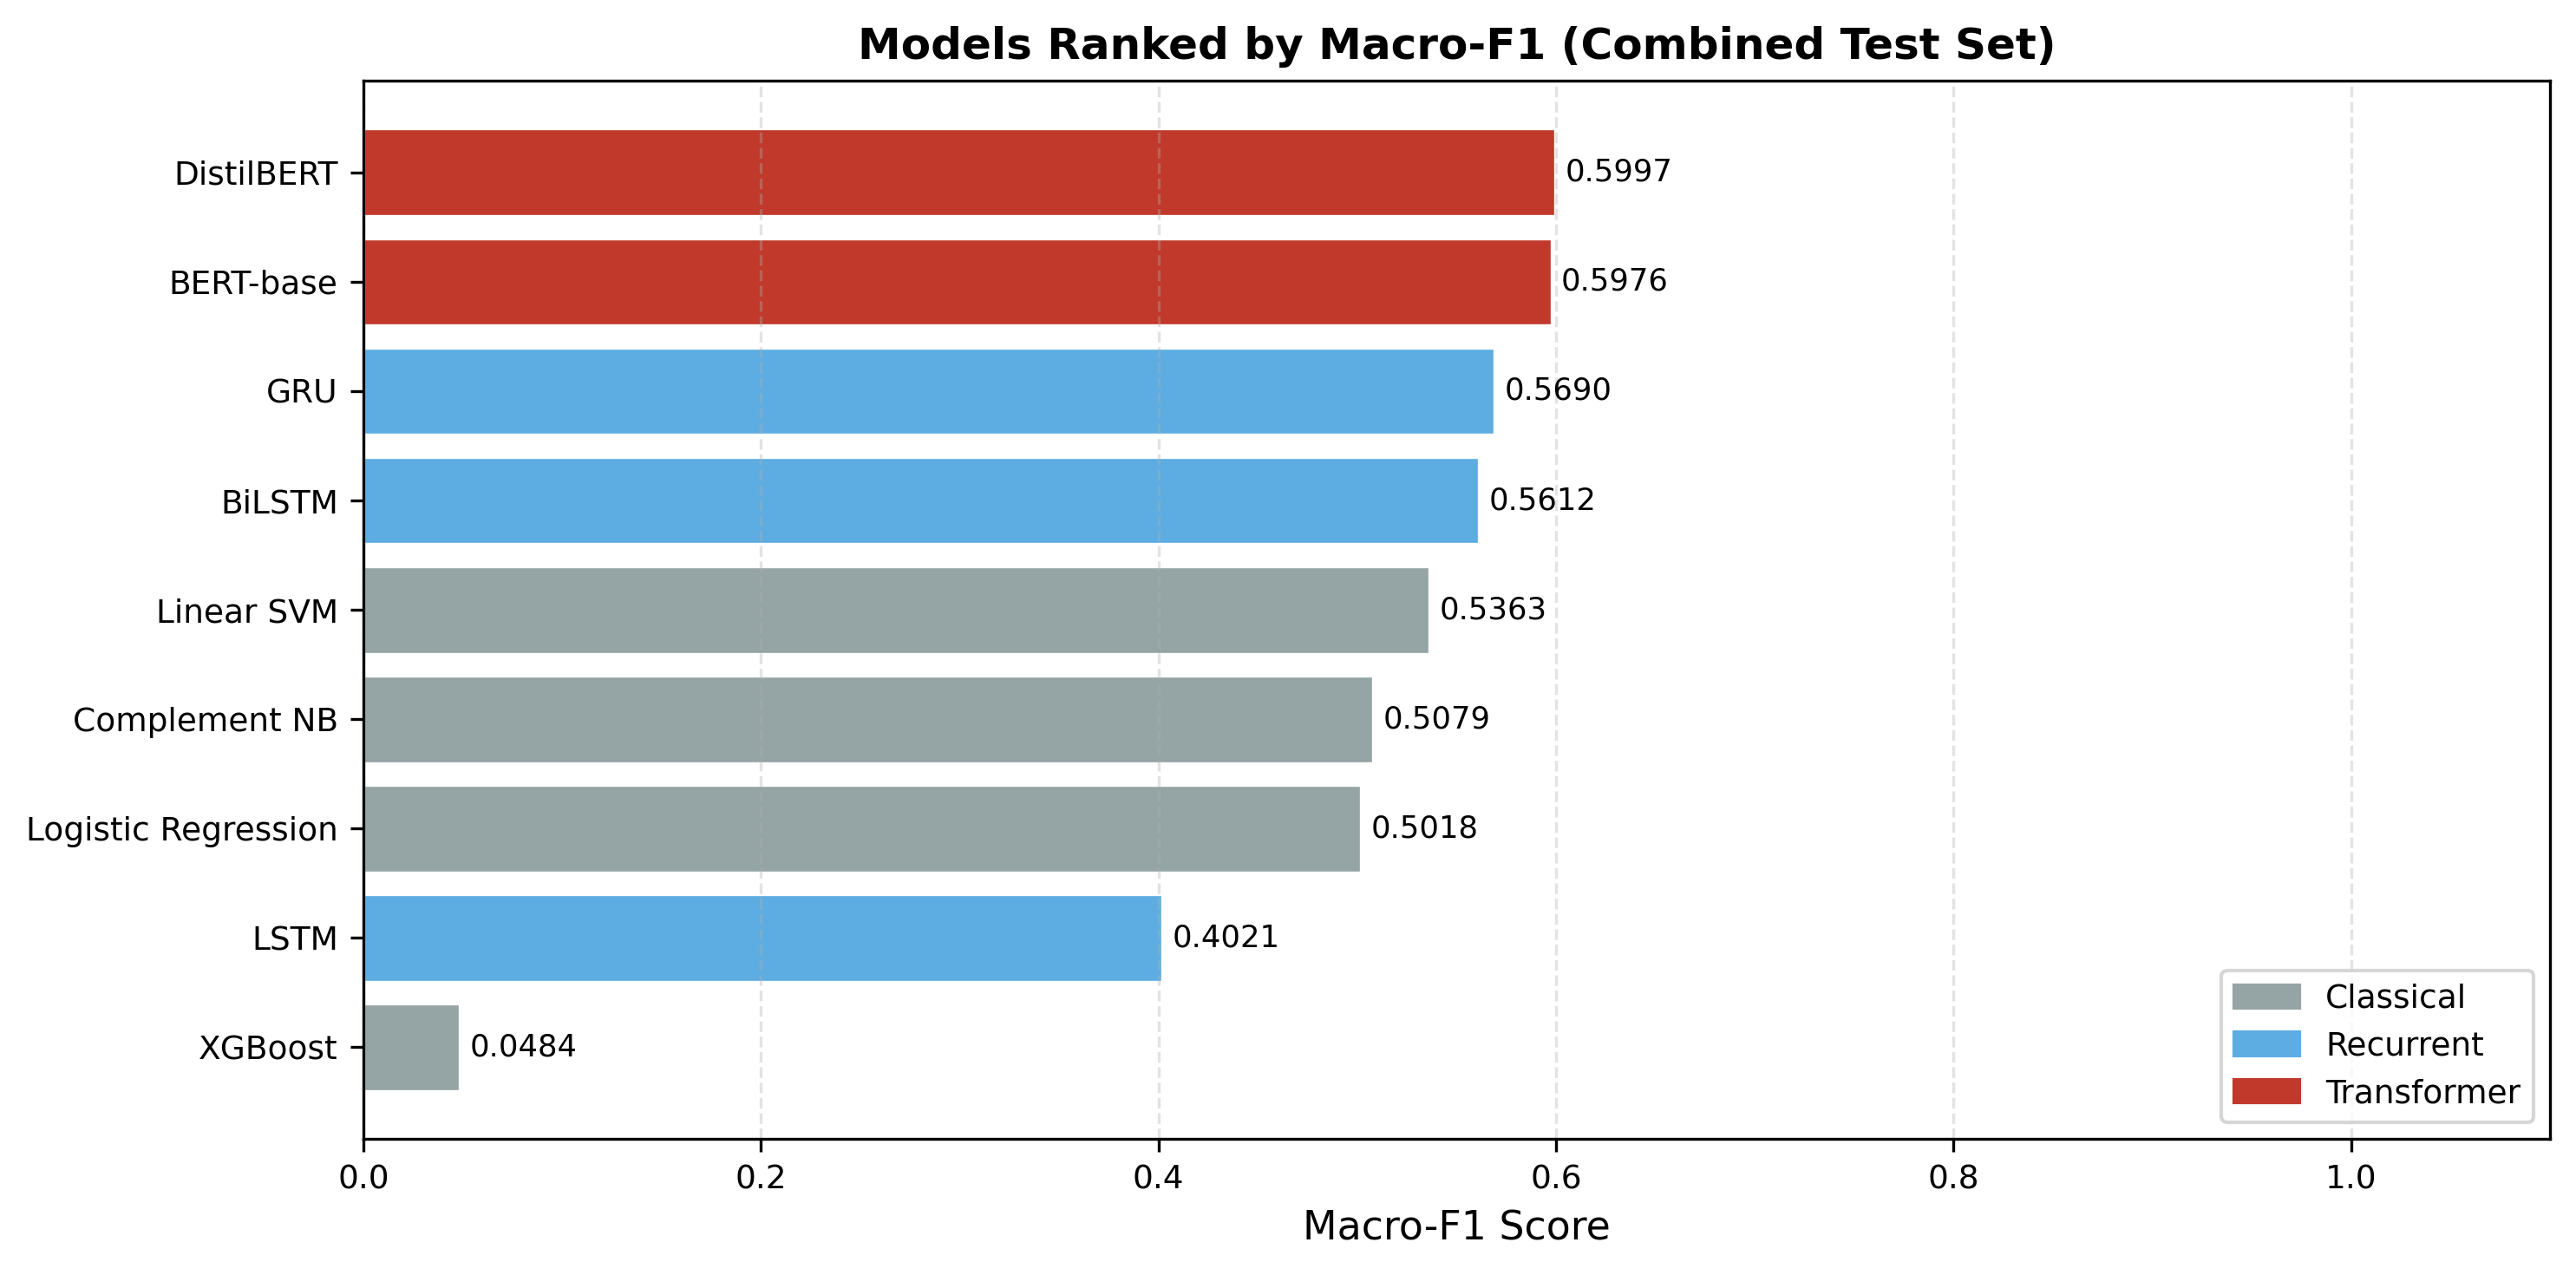

Saved: plot2_macro_f1_ranked.png


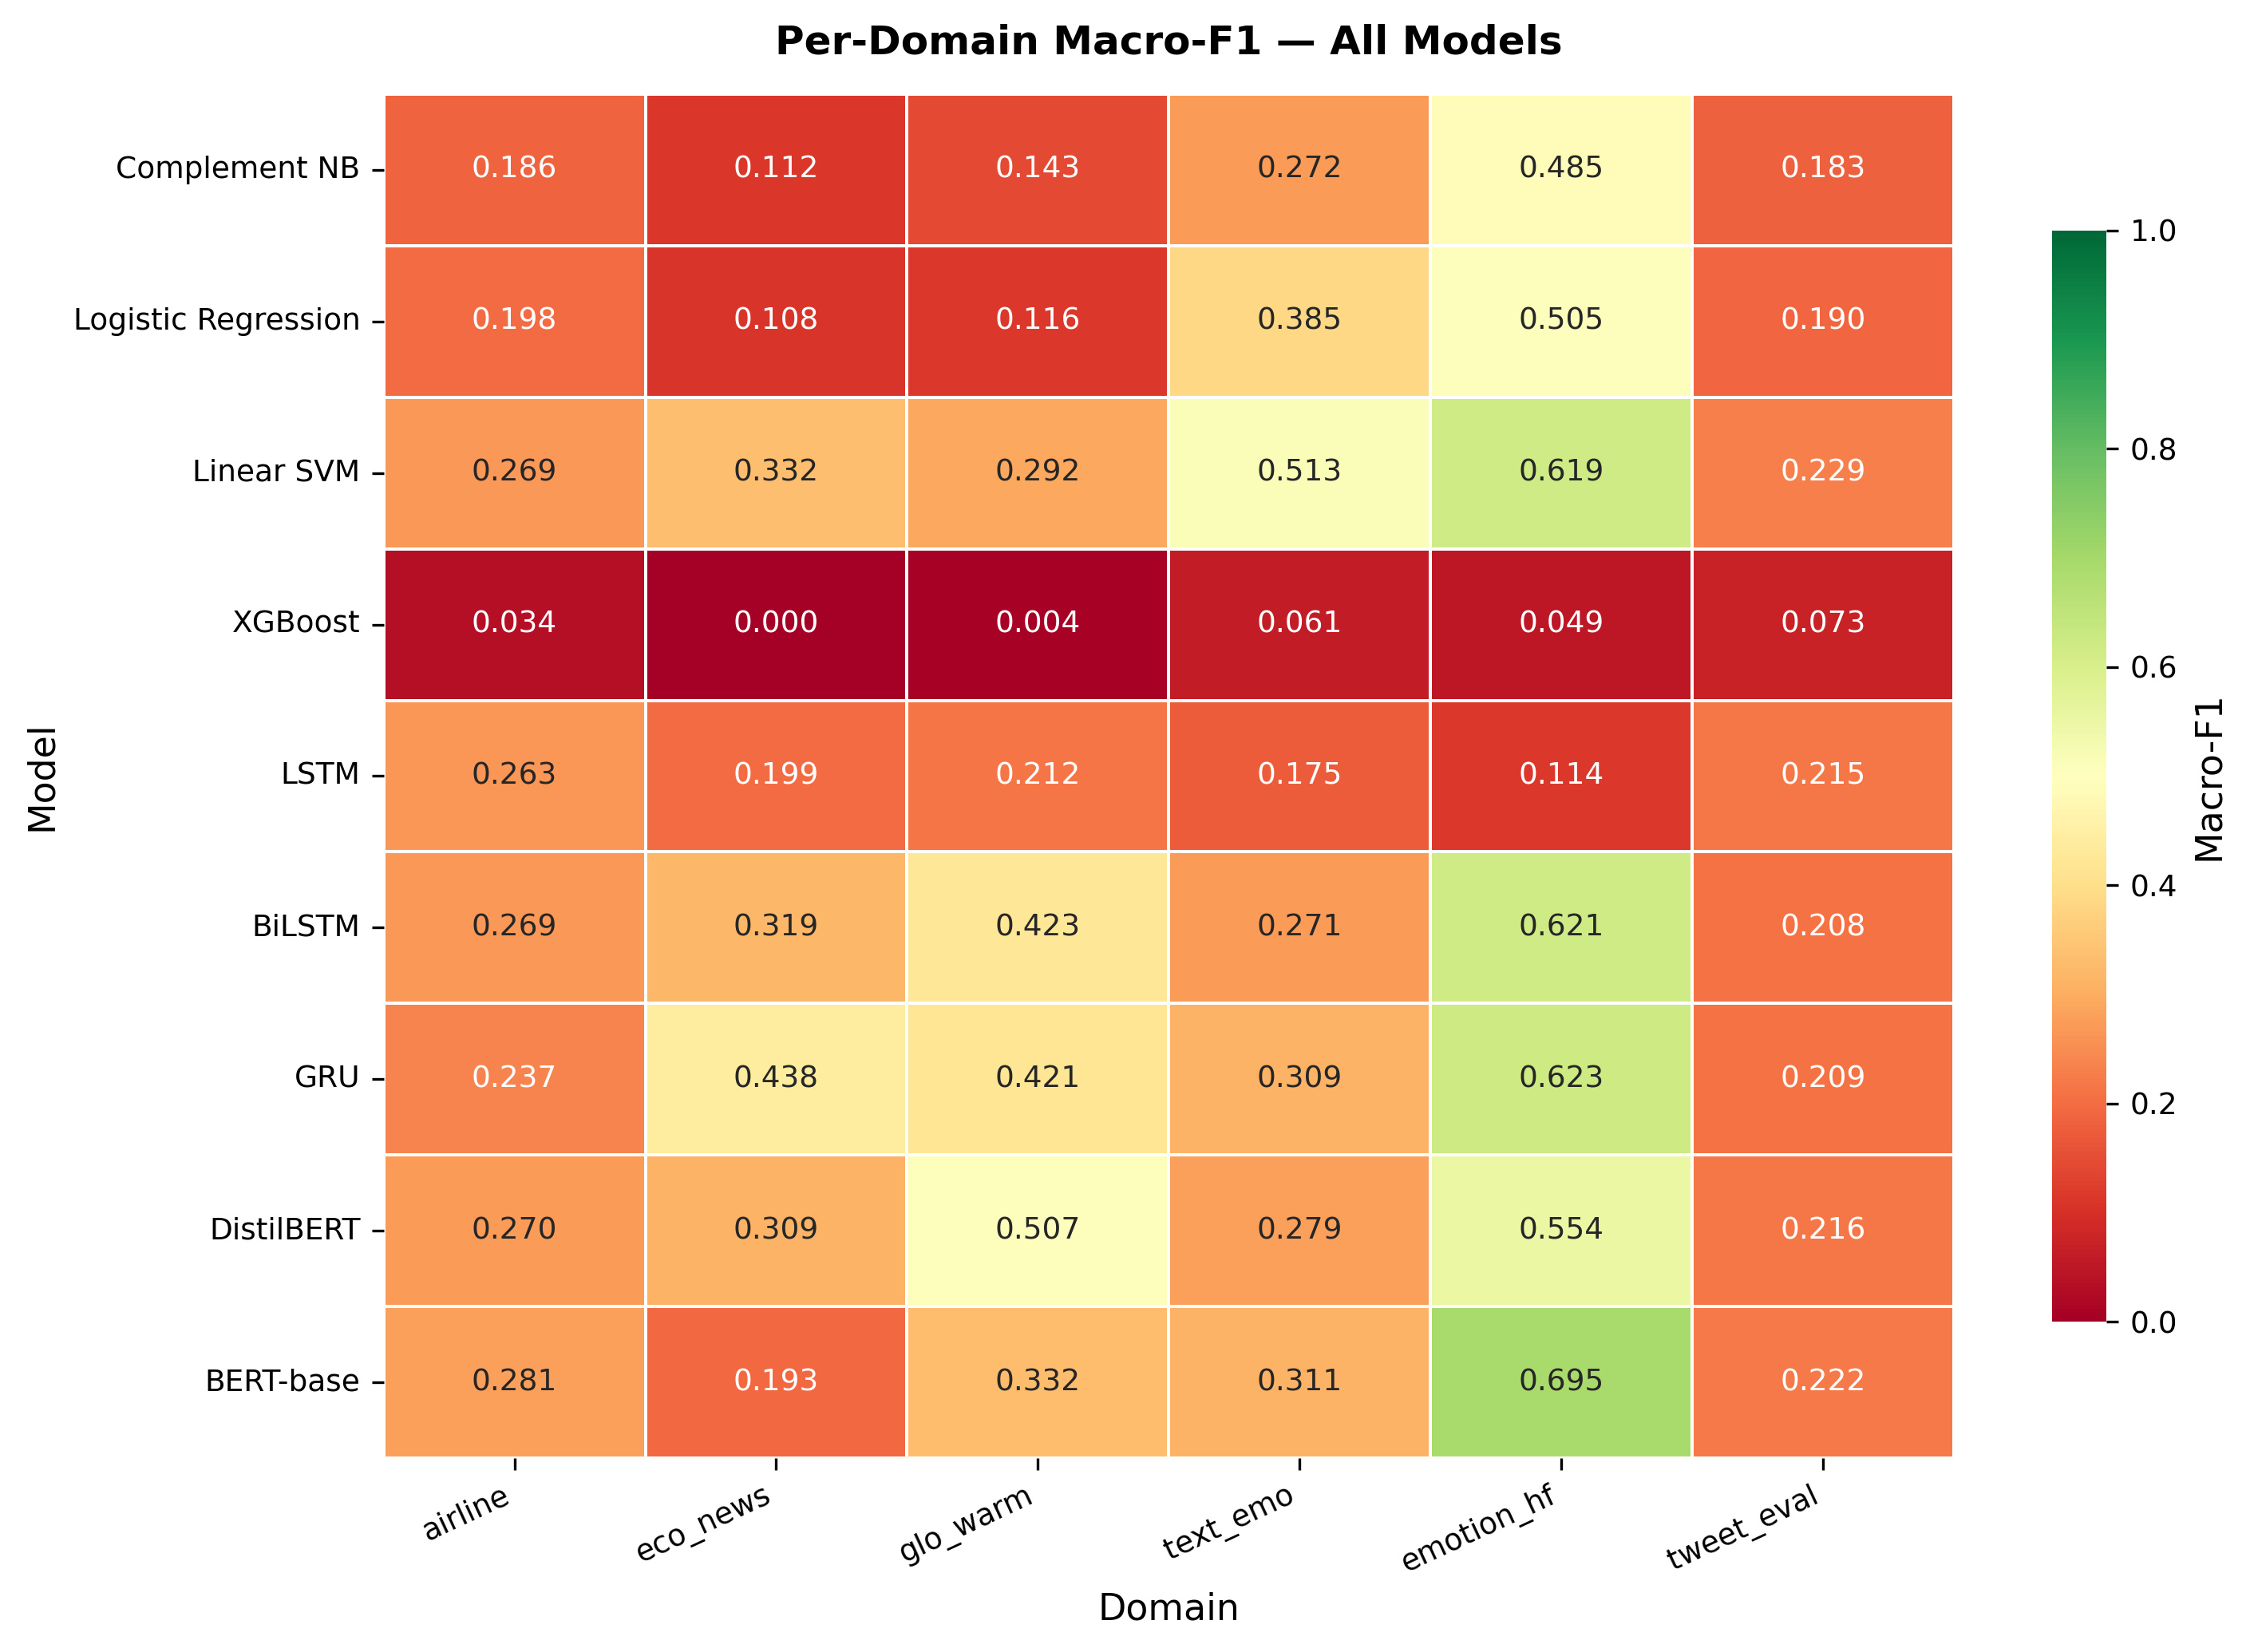

Saved: plot3_per_domain_heatmap.png


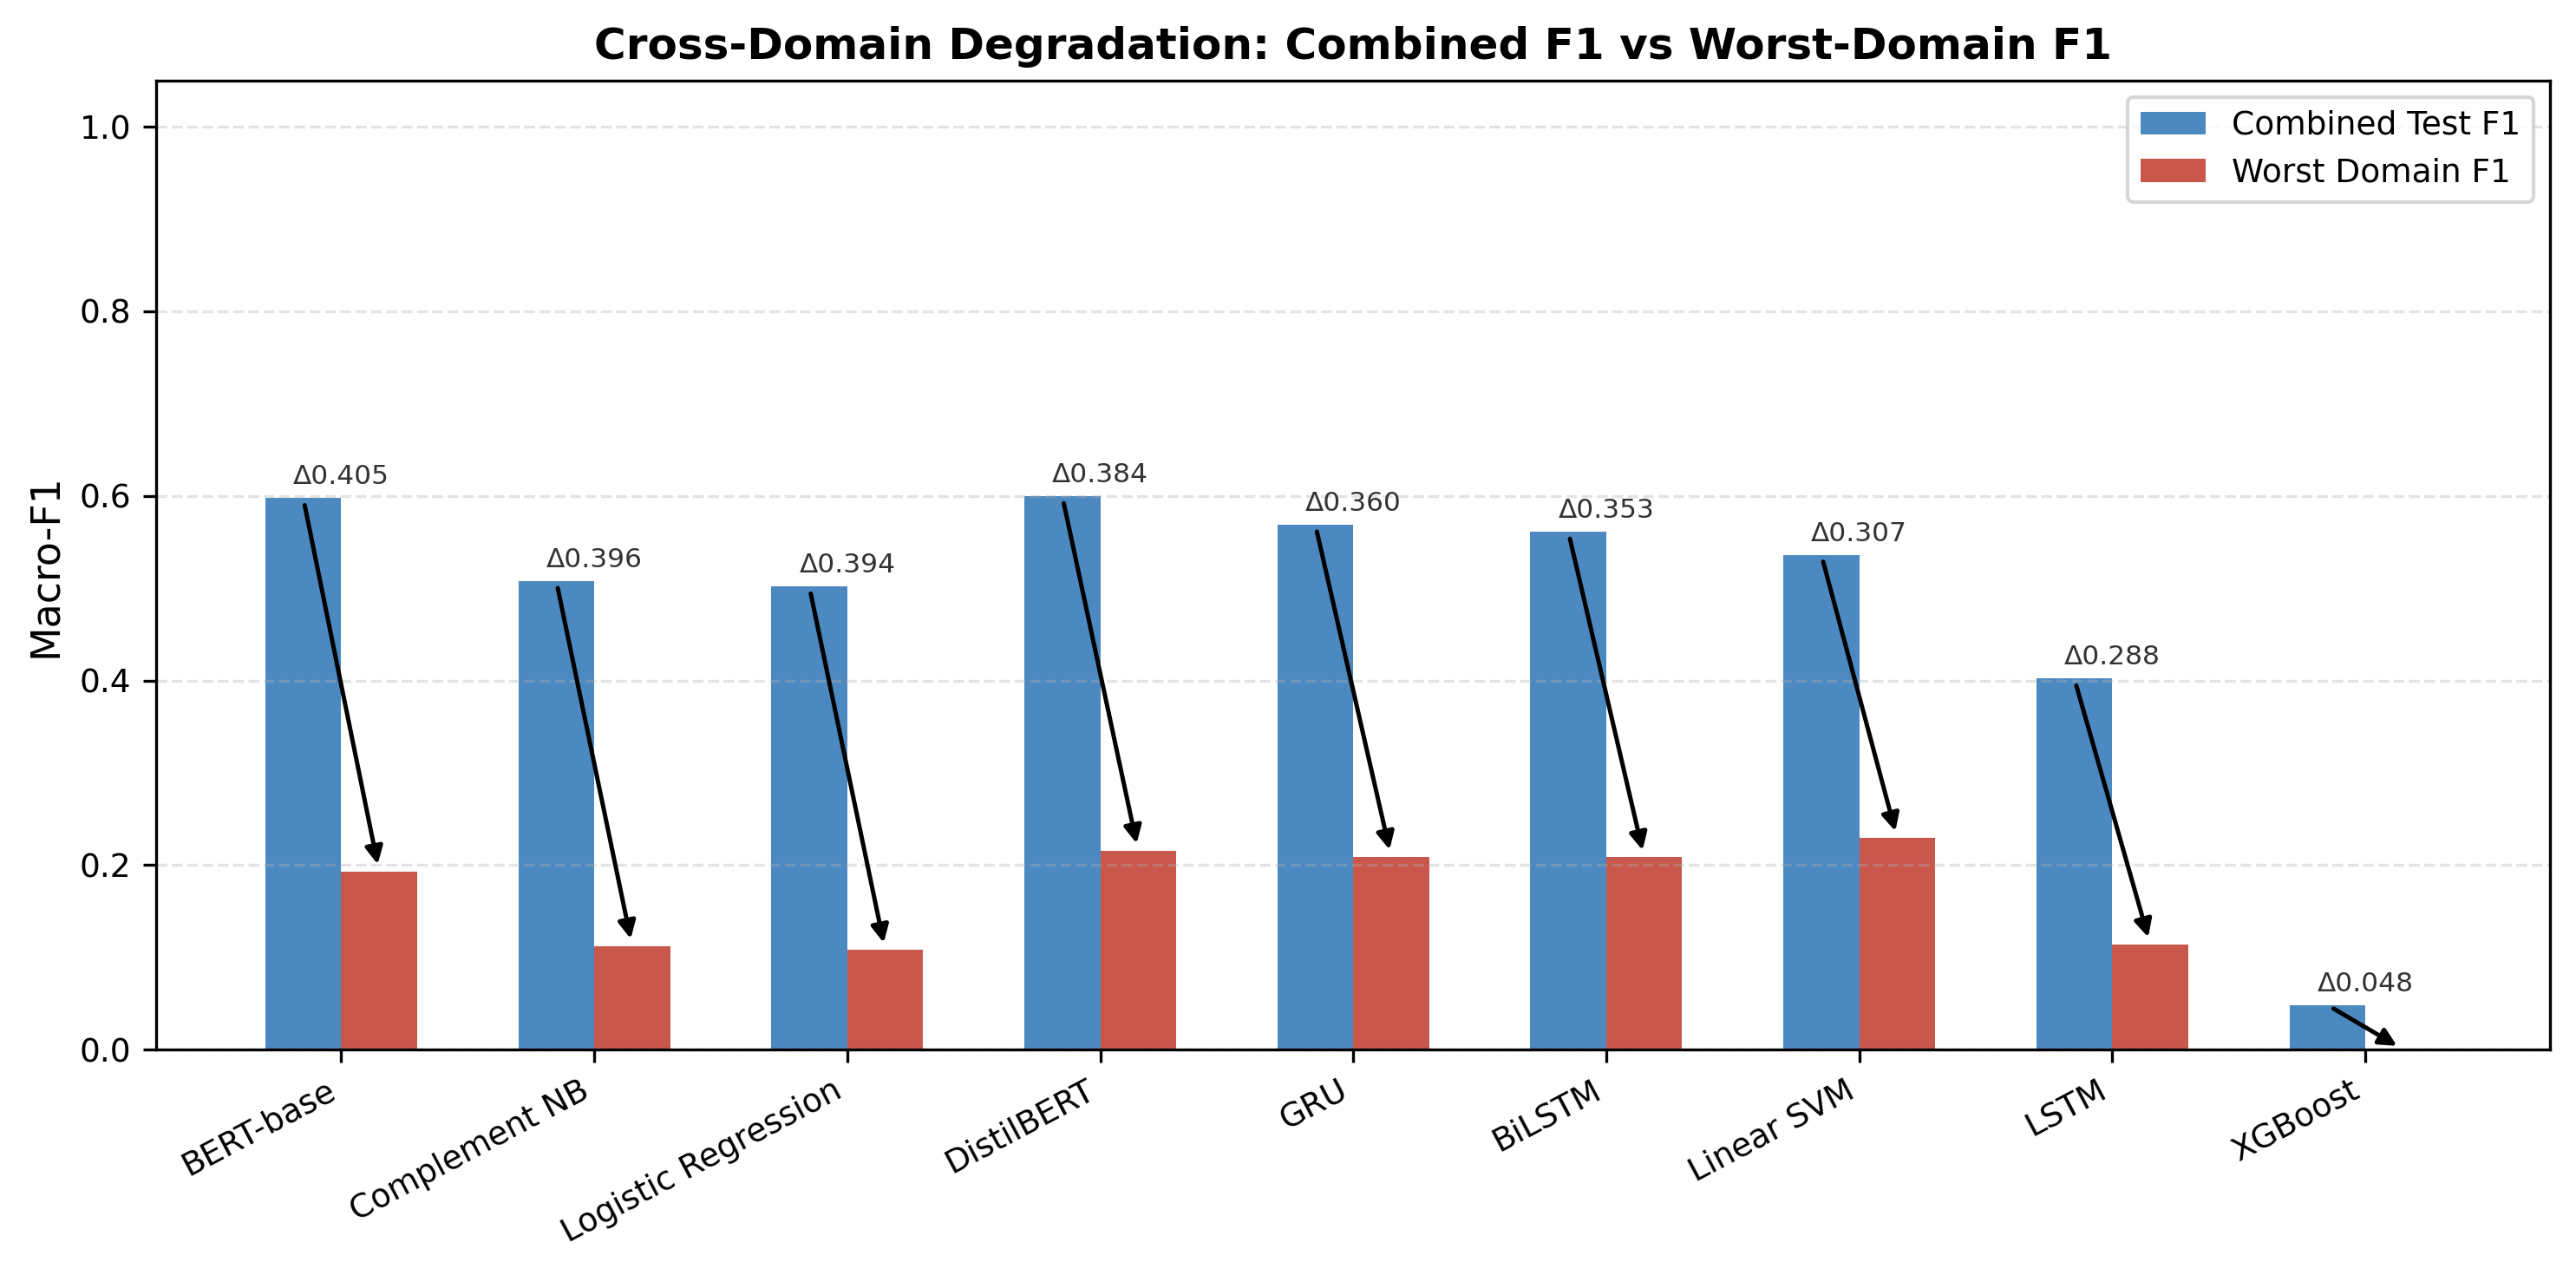

Saved: plot4_cross_domain_degradation.png


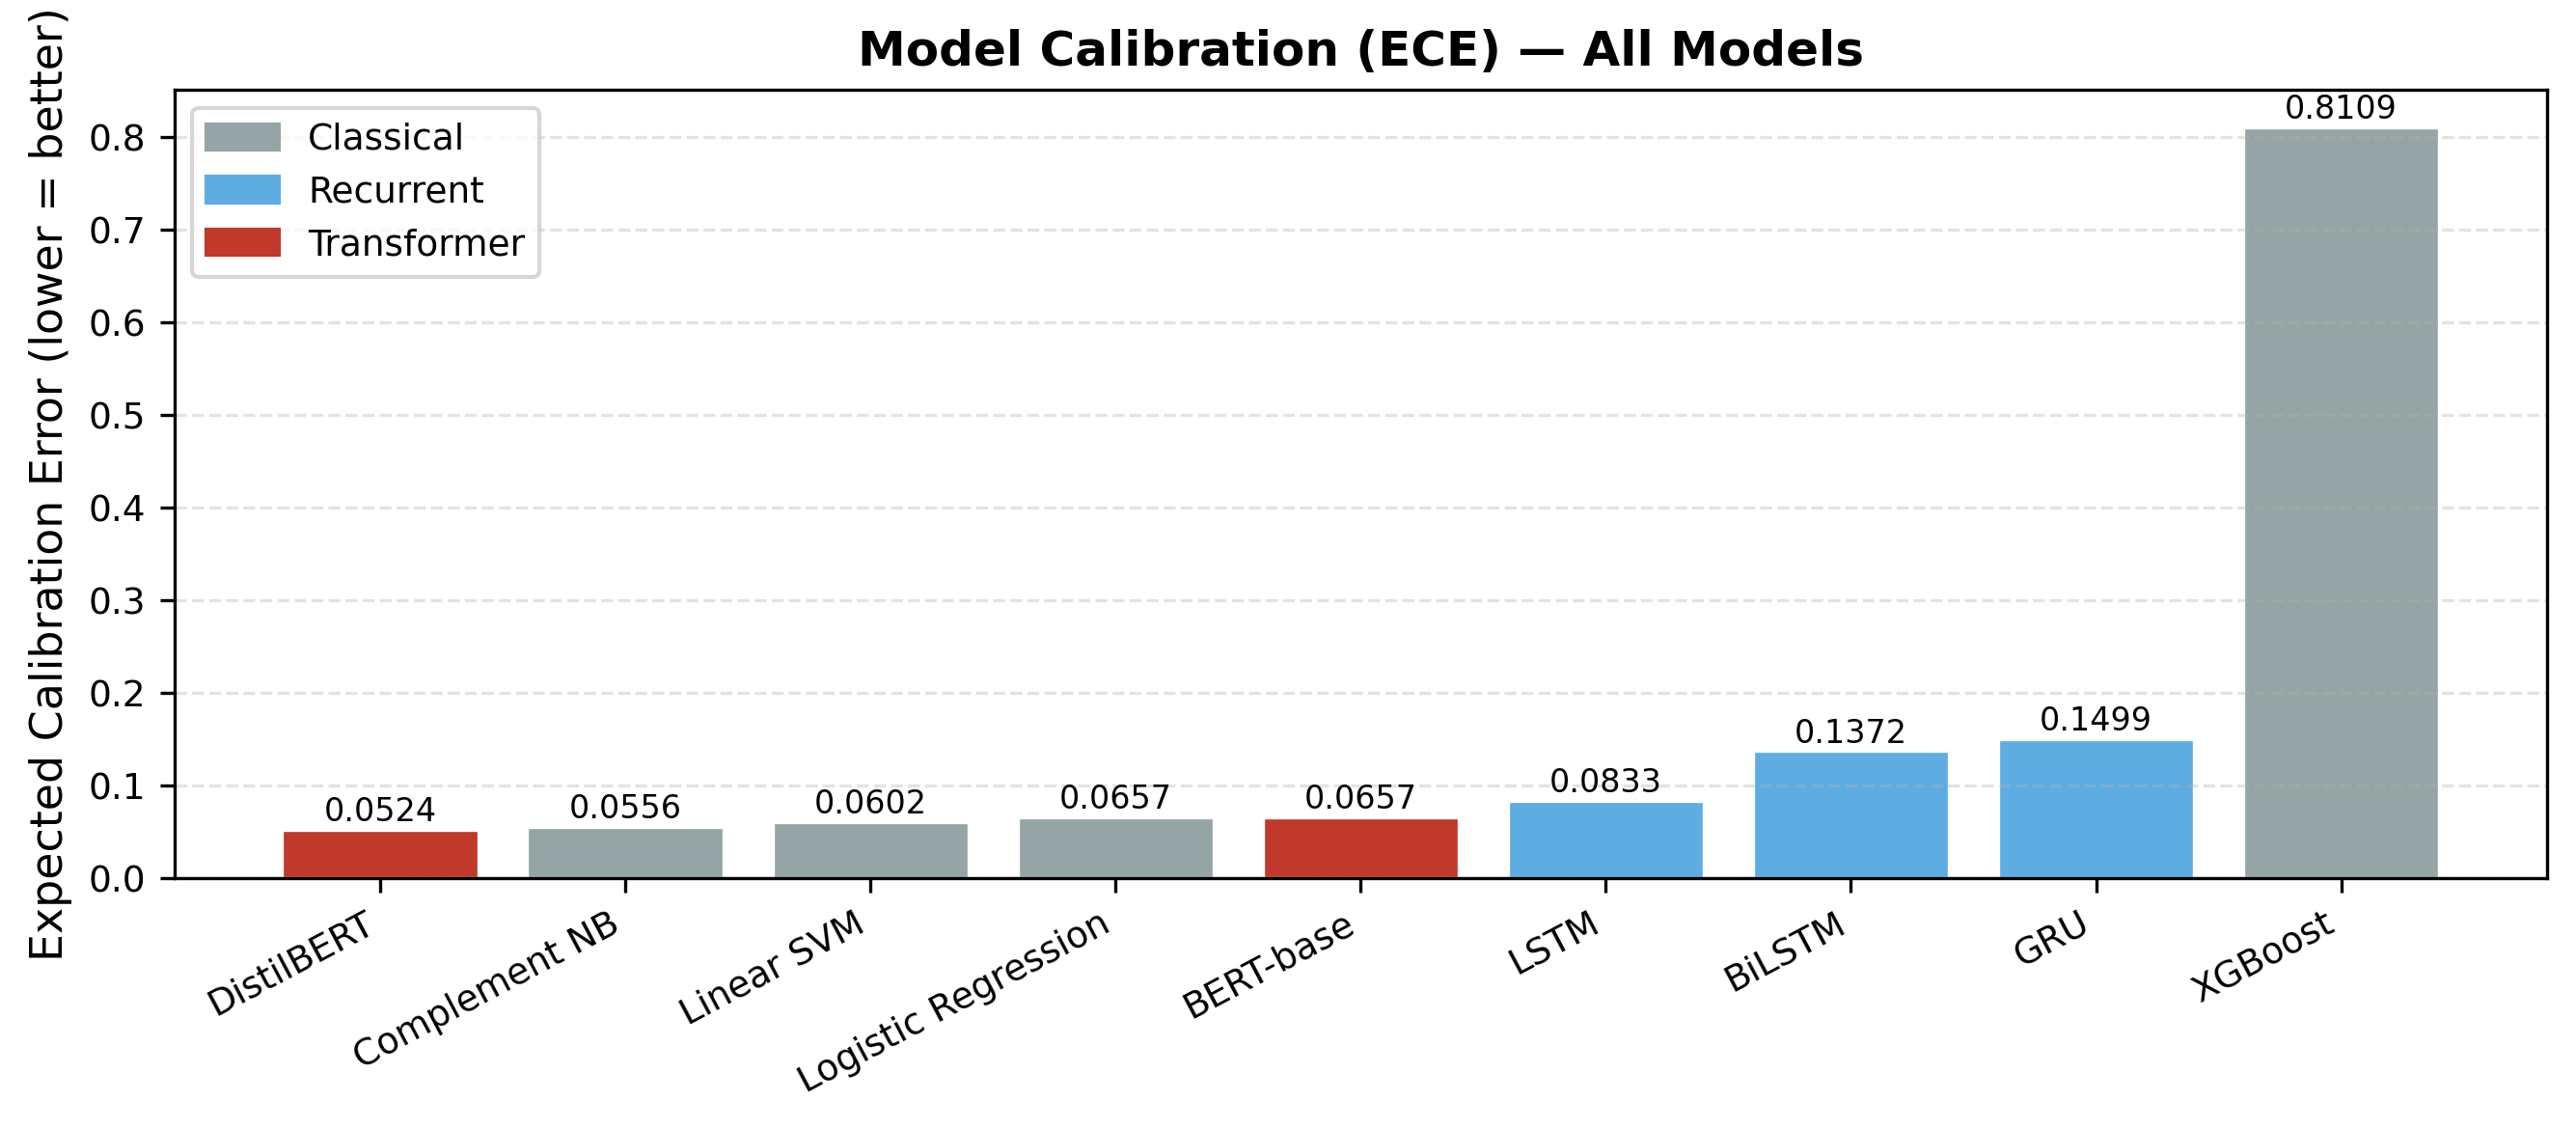

Saved: plot5_ece_calibration.png


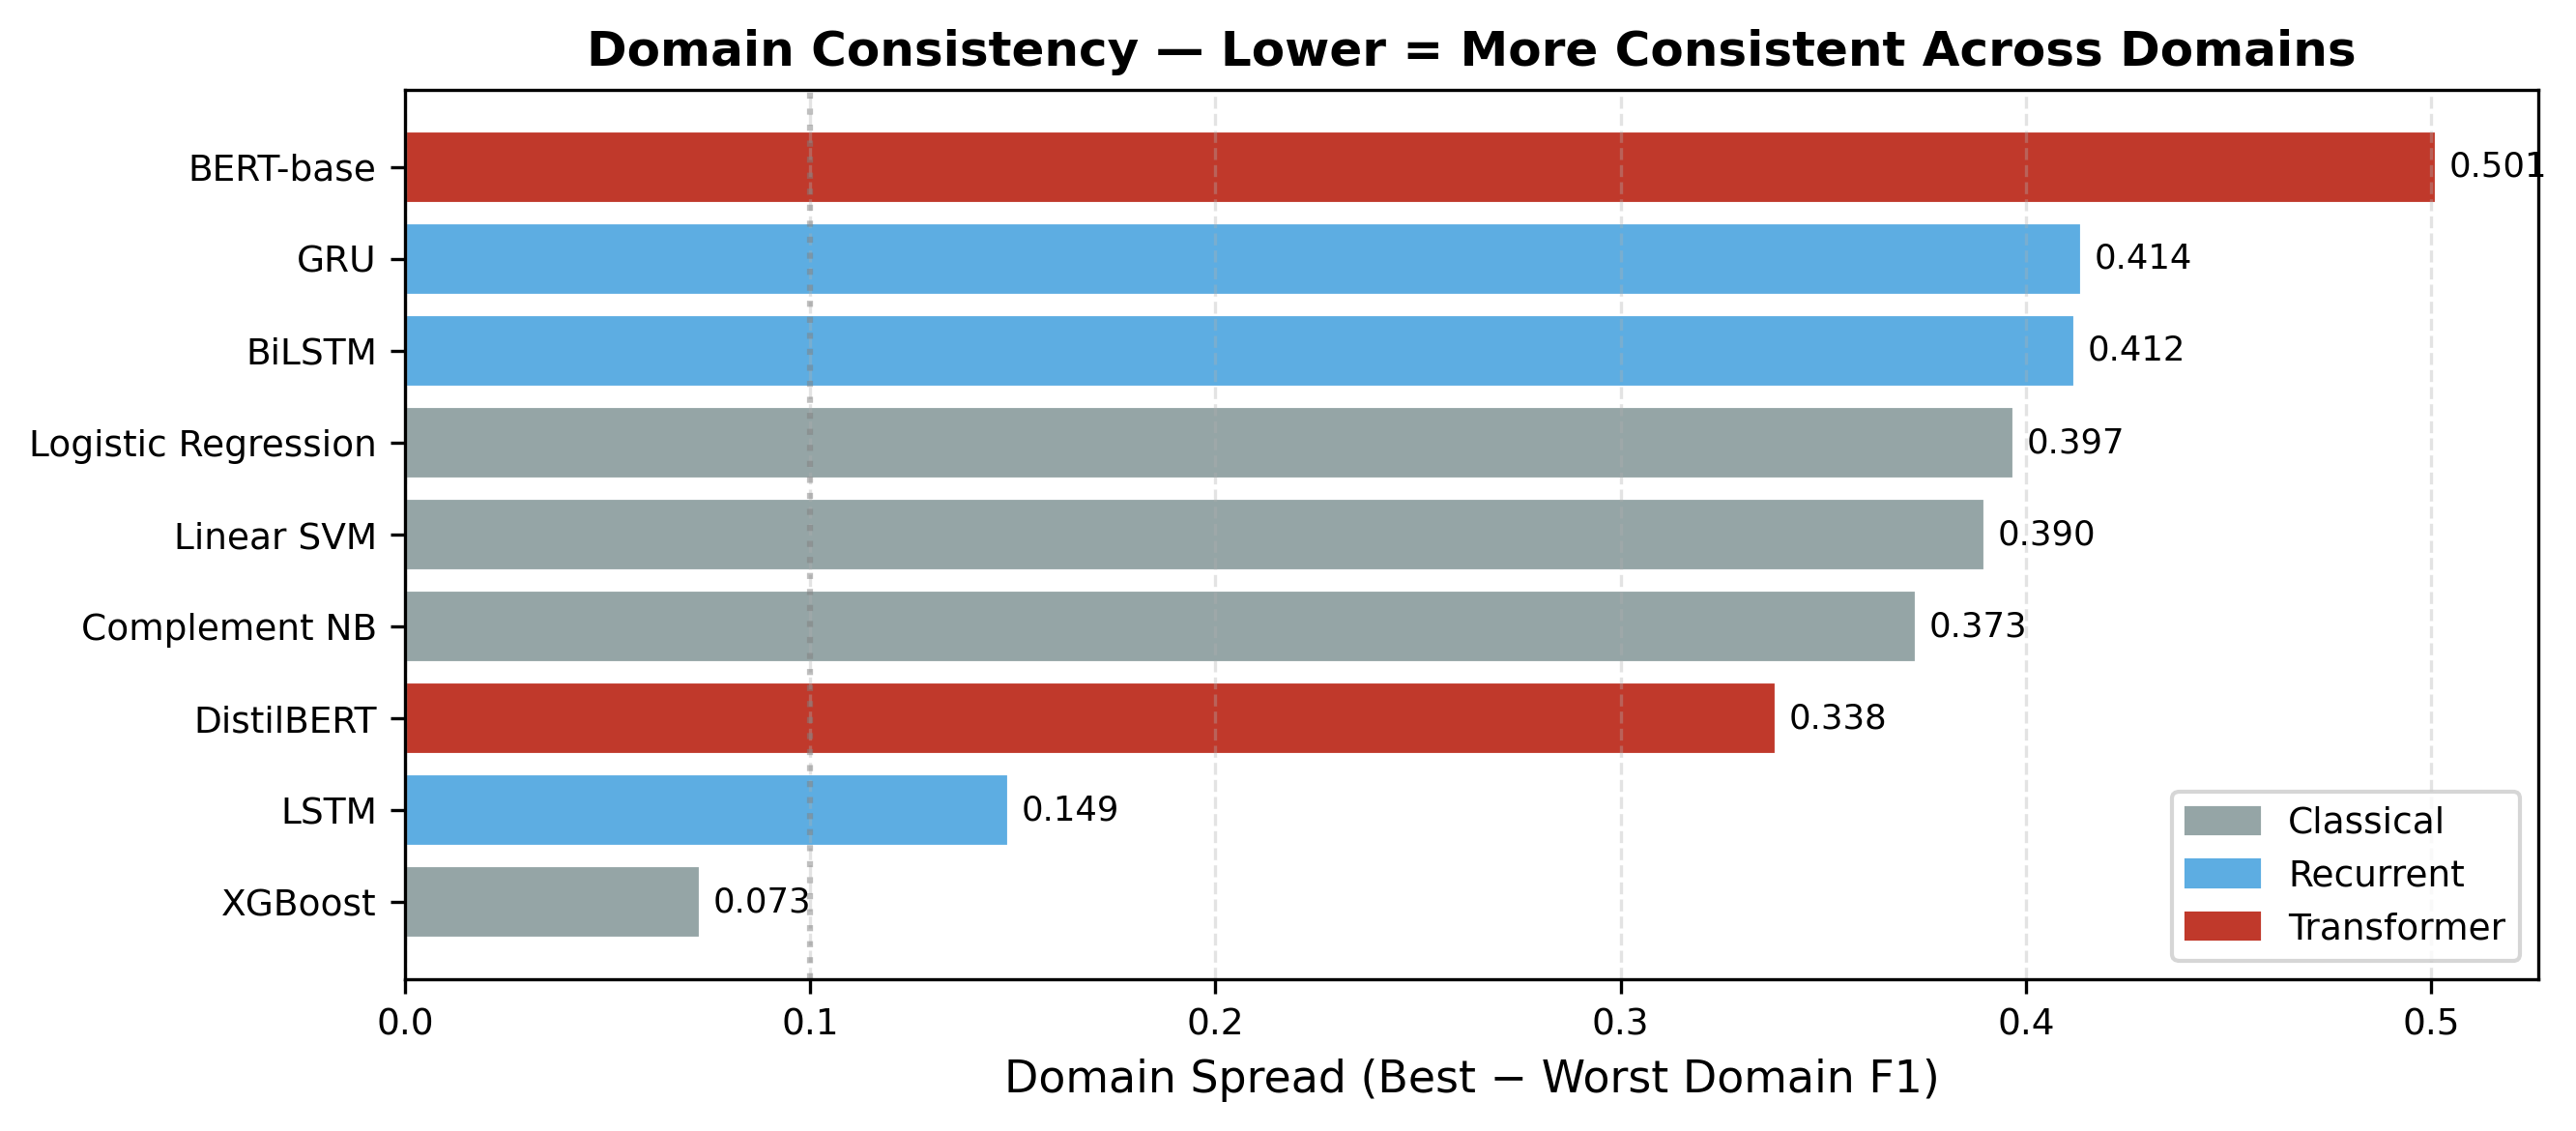

Saved: plot6_domain_spread.png

All outputs saved to: outputs
  master_results.csv
  per_domain_f1.csv
  cross_domain_degradation.csv
  plot1_all_models_metrics.png
  plot2_macro_f1_ranked.png
  plot3_per_domain_heatmap.png
  plot4_cross_domain_degradation.png
  plot5_ece_calibration.png
  plot6_domain_spread.png

✓ Cell 6 complete.


In [7]:
# ============================================================
# CELL 6 — Final Results Tables + All Plots
# Run after Cells 2, 4, 5. Produces all paper figures.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
})

# ── Load all results ──────────────────────────────────────────
cl_df    = pd.read_csv(f"{CFG.SAVE_DIR}/classical_results.csv")
rnn_df   = pd.read_csv(f"{CFG.SAVE_DIR}/rnn_results.csv")
trans_df = pd.read_csv(f"{CFG.SAVE_DIR}/transformer_results.csv")

with open(f"{CFG.SAVE_DIR}/domain_results_classical.pkl","rb") as f:
    dr_cl = pickle.load(f)
with open(f"{CFG.SAVE_DIR}/domain_results_rnn.pkl","rb") as f:
    dr_rnn = pickle.load(f)
with open(f"{CFG.SAVE_DIR}/domain_results_trans.pkl","rb") as f:
    dr_trans = pickle.load(f)

# ── Master results table ──────────────────────────────────────
all_results = pd.concat([cl_df, rnn_df, trans_df], ignore_index=True)
all_results["Category"] = (
    ["Classical"] * len(cl_df) +
    ["Recurrent"] * len(rnn_df) +
    ["Transformer"] * len(trans_df)
)

print("=" * 75)
print("MASTER RESULTS TABLE — All Models, Combined Test Set")
print("=" * 75)
print(all_results.to_string(index=False))
all_results.to_csv(f"{CFG.SAVE_DIR}/master_results.csv", index=False)

# ── Per-domain macro-F1 table ─────────────────────────────────
all_domain = {**dr_cl, **dr_rnn, **dr_trans}
dom_f1_rows = []
for model_name, dom_dict in all_domain.items():
    row = {"Model": model_name}
    for dom in CFG.DOMAIN_NAMES:
        row[dom] = dom_dict[dom]["Macro-F1"] if dom in dom_dict else None
    dom_f1_rows.append(row)
dom_f1_df = pd.DataFrame(dom_f1_rows)

print("\n" + "=" * 75)
print("PER-DOMAIN MACRO-F1")
print("=" * 75)
print(dom_f1_df.to_string(index=False))
dom_f1_df.to_csv(f"{CFG.SAVE_DIR}/per_domain_f1.csv", index=False)

# ── Cross-domain degradation ──────────────────────────────────
# How much does each model drop from combined-test F1 to worst domain F1?
best_model   = all_results.loc[all_results["Macro-F1"].idxmax(), "Model"]
combined_f1  = all_results.set_index("Model")["Macro-F1"].to_dict()

deg_rows = []
for model_name, dom_dict in all_domain.items():
    domain_f1s = [dom_dict[d]["Macro-F1"] for d in CFG.DOMAIN_NAMES if d in dom_dict]
    if not domain_f1s: continue
    worst = min(domain_f1s)
    best  = max(domain_f1s)
    combined = combined_f1.get(model_name, None)
    deg_rows.append({
        "Model":           model_name,
        "Combined F1":     combined,
        "Best Domain F1":  round(best,  4),
        "Worst Domain F1": round(worst, 4),
        "Degradation":     round(combined - worst, 4) if combined else None,
        "Domain Spread":   round(best - worst, 4),
    })
deg_df = pd.DataFrame(deg_rows)
print("\n" + "=" * 75)
print("CROSS-DOMAIN DEGRADATION")
print("=" * 75)
print(deg_df.to_string(index=False))
deg_df.to_csv(f"{CFG.SAVE_DIR}/cross_domain_degradation.csv", index=False)

# ─────────────────────────────────────────────────────────────
# PLOT 1: All-model metric comparison (grouped bar)
# ─────────────────────────────────────────────────────────────
metrics   = ["Accuracy","Precision","Recall","Macro-F1","Weighted-F1"]
models    = all_results["Model"].tolist()
cats      = all_results["Category"].tolist()
x         = np.arange(len(models))
width     = 0.15
COLORS    = ["#2196F3","#4CAF50","#FF9800","#E91E63","#9C27B0"]
CAT_COLOR = {"Classical":"#95A5A6","Recurrent":"#5DADE2","Transformer":"#C0392B"}

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics, COLORS)):
    vals = all_results[metric].tolist()
    bars = ax.bar(x + i*width, vals, width, label=metric,
                  color=color, alpha=0.85, edgecolor="white", linewidth=0.5)

ax.set_xticks(x + width*2)
ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Performance Comparison Across All Models and Metrics",
             fontweight="bold")

# Category background bands
prev = -1
for i, (cat, model) in enumerate(zip(cats, models)):
    if cat != prev:
        ax.axvline(i - 0.3, color="grey", linestyle="--", alpha=0.3, linewidth=0.8)
        ax.text(i + 0.3, 1.02, cat, fontsize=8, color=CAT_COLOR[cat], fontweight="bold")
        prev = cat

ax.legend(loc="upper left", ncol=5, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/plot1_all_models_metrics.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot1_all_models_metrics.png")

# ─────────────────────────────────────────────────────────────
# PLOT 2: Macro-F1 ranked bar chart (single metric, clean)
# ─────────────────────────────────────────────────────────────
sorted_df = all_results.sort_values("Macro-F1")
bar_colors = [CAT_COLOR[c] for c in sorted_df["Category"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_df["Model"], sorted_df["Macro-F1"],
               color=bar_colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, sorted_df["Macro-F1"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8.5)

ax.set_xlabel("Macro-F1 Score"); ax.set_xlim(0, 1.1)
ax.set_title("Models Ranked by Macro-F1 (Combined Test Set)", fontweight="bold")
patches = [mpatches.Patch(color=v, label=k) for k,v in CAT_COLOR.items()]
ax.legend(handles=patches, loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/plot2_macro_f1_ranked.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot2_macro_f1_ranked.png")

# ─────────────────────────────────────────────────────────────
# PLOT 3: Per-domain Macro-F1 heatmap
# ─────────────────────────────────────────────────────────────
heatmap_data = dom_f1_df.set_index("Model")[CFG.DOMAIN_NAMES].astype(float)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label":"Macro-F1","shrink":0.8},
    annot_kws={"size":9}
)
ax.set_title("Per-Domain Macro-F1 — All Models", fontweight="bold", pad=12)
ax.set_xlabel("Domain"); ax.set_ylabel("Model")
ax.set_xticklabels(CFG.DOMAIN_NAMES, rotation=25, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/plot3_per_domain_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot3_per_domain_heatmap.png")

# ─────────────────────────────────────────────────────────────
# PLOT 4: Cross-domain degradation chart
# ─────────────────────────────────────────────────────────────
deg_plot = deg_df.dropna().sort_values("Degradation", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(deg_plot))
w = 0.3
ax.bar(x - w/2, deg_plot["Combined F1"],  w, label="Combined Test F1",
       color="#2E75B6", alpha=0.85)
ax.bar(x + w/2, deg_plot["Worst Domain F1"], w, label="Worst Domain F1",
       color="#C0392B", alpha=0.85)

for i, (_, row) in enumerate(deg_plot.iterrows()):
    ax.annotate("", xy=(i+w/2, row["Worst Domain F1"]),
                xytext=(i-w/2, row["Combined F1"]),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2))
    ax.text(i, max(row["Combined F1"], row["Worst Domain F1"]) + 0.015,
            f"Δ{row['Degradation']:.3f}", ha="center", fontsize=7.5, color="#333")

ax.set_xticks(x)
ax.set_xticklabels(deg_plot["Model"], rotation=28, ha="right")
ax.set_ylabel("Macro-F1"); ax.set_ylim(0, 1.05)
ax.set_title("Cross-Domain Degradation: Combined F1 vs Worst-Domain F1",
             fontweight="bold")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/plot4_cross_domain_degradation.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot4_cross_domain_degradation.png")

# ─────────────────────────────────────────────────────────────
# PLOT 5: ECE calibration comparison
# ─────────────────────────────────────────────────────────────
ece_df = all_results[all_results["ECE"] != "—"].copy()
ece_df["ECE"] = pd.to_numeric(ece_df["ECE"])
ece_sorted = ece_df.sort_values("ECE")

fig, ax = plt.subplots(figsize=(9, 4))
bar_col = [CAT_COLOR[c] for c in ece_sorted["Category"]]
bars = ax.bar(ece_sorted["Model"], ece_sorted["ECE"],
              color=bar_col, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, ece_sorted["ECE"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002, f"{val:.4f}",
            ha="center", va="bottom", fontsize=8)

ax.set_xticklabels(ece_sorted["Model"], rotation=28, ha="right")
ax.set_ylabel("Expected Calibration Error (lower = better)")
ax.set_title("Model Calibration (ECE) — All Models", fontweight="bold")
patches = [mpatches.Patch(color=v, label=k) for k,v in CAT_COLOR.items()]
ax.legend(handles=patches)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/plot5_ece_calibration.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot5_ece_calibration.png")

# ─────────────────────────────────────────────────────────────
# PLOT 6: Domain spread (best - worst domain F1 per model)
# Shows which models generalise consistently
# ─────────────────────────────────────────────────────────────
spread_sorted = deg_df.dropna().sort_values("Domain Spread", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bar_col2 = []
for m in spread_sorted["Model"]:
    cat = all_results.loc[all_results["Model"]==m,"Category"].values
    bar_col2.append(CAT_COLOR[cat[0]] if len(cat) else "#aaa")

bars = ax.barh(spread_sorted["Model"], spread_sorted["Domain Spread"],
               color=bar_col2, edgecolor="white")
for bar, val in zip(bars, spread_sorted["Domain Spread"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8.5)

ax.set_xlabel("Domain Spread (Best − Worst Domain F1)")
ax.set_title("Domain Consistency — Lower = More Consistent Across Domains",
             fontweight="bold")
ax.axvline(0.1, color="grey", linestyle=":", alpha=0.5)
patches = [mpatches.Patch(color=v, label=k) for k,v in CAT_COLOR.items()]
ax.legend(handles=patches, loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(f"{CFG.SAVE_DIR}/plot6_domain_spread.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot6_domain_spread.png")

# ── Final file list ───────────────────────────────────────────
print(f"\n{'='*55}")
print(f"All outputs saved to: {CFG.SAVE_DIR}")
print(f"{'='*55}")
outputs = [
    "master_results.csv", "per_domain_f1.csv",
    "cross_domain_degradation.csv",
    "plot1_all_models_metrics.png",
    "plot2_macro_f1_ranked.png",
    "plot3_per_domain_heatmap.png",
    "plot4_cross_domain_degradation.png",
    "plot5_ece_calibration.png",
    "plot6_domain_spread.png",
]
for f in outputs:
    print(f"  {f}")

print("\n✓ Cell 6 complete.")